In [8]:
# ============================================================
# Task 4: Visualization & Reporting
# Food Delivery Pattern Analysis
# ============================================================

import os
import ast
import warnings
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

warnings.filterwarnings("ignore")

# ----------------------------
# Visual Style
# ----------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# ----------------------------
# Paths
# ----------------------------
BASE_DIR = "output"   # because your notebook is currently running inside the data folder

PROCESSED_DIR = os.path.join(BASE_DIR, "processed")
TRANSACTIONS_DIR = os.path.join(BASE_DIR, "transactions")
FIGURES_DIR = os.path.join(BASE_DIR, "figures")

os.makedirs(FIGURES_DIR, exist_ok=True)

TRANSACTIONS_PATH = os.path.join(TRANSACTIONS_DIR, "transactions.csv")
MEALS_PATH = os.path.join(PROCESSED_DIR, "meals_cleaned.csv")
REVIEWS_PATH = os.path.join(PROCESSED_DIR, "reviews.csv")
REVIEWS_SENTIMENT_PATH = os.path.join(PROCESSED_DIR, "reviews_with_sentiment.csv")
ASSOCIATION_RULES_PATH = os.path.join(PROCESSED_DIR, "association_rules.csv")
PAGERANK_PATH = os.path.join(PROCESSED_DIR, "pagerank_results.csv")

print("✅ Setup completed successfully")
print("Working directory:", os.getcwd())
print("Figures directory:", FIGURES_DIR)

✅ Setup completed successfully
Working directory: d:\sixth term\practical data mining\New folder\Food-Delivery-Pattern-Analysis\data
Figures directory: output\figures


In [9]:
# ============================================================
# Helper Functions
# ============================================================

def save_figure(filename):
    """Save current matplotlib figure into the figures directory."""
    path = os.path.join(FIGURES_DIR, filename)
    plt.savefig(path, bbox_inches="tight", dpi=150)
    print(f"✅ Saved: {path}")


def split_items(series):
    """Split comma-separated transaction items into a flat list."""
    items = []
    for value in series.dropna():
        items.extend([x.strip() for x in str(value).split(",") if x.strip()])
    return items


def add_bar_labels(ax, orientation="vertical", padding=3, fontsize=9):
    """Add value labels to bar charts."""
    if orientation == "vertical":
        for bar in ax.patches:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + padding,
                f"{int(height)}",
                ha="center",
                va="bottom",
                fontsize=fontsize
            )
    else:
        for bar in ax.patches:
            width = bar.get_width()
            ax.text(
                width + padding,
                bar.get_y() + bar.get_height() / 2,
                f"{int(width)}",
                ha="left",
                va="center",
                fontsize=fontsize
            )

In [10]:
# ============================================================
# Load Data
# ============================================================

required_files = {
    "Transactions": TRANSACTIONS_PATH,
    "Meals": MEALS_PATH,
    "Reviews": REVIEWS_PATH
}

for name, path in required_files.items():
    print(f"{name}: {'✅ Found' if os.path.exists(path) else '❌ Missing'} -> {path}")

transactions_df = pd.read_csv(TRANSACTIONS_PATH)
meals_df = pd.read_csv(MEALS_PATH) if os.path.exists(MEALS_PATH) else None
reviews_df = pd.read_csv(REVIEWS_PATH) if os.path.exists(REVIEWS_PATH) else None

# Optional outputs from other persons
association_rules_df = pd.read_csv(ASSOCIATION_RULES_PATH) if os.path.exists(ASSOCIATION_RULES_PATH) else None
pagerank_df = pd.read_csv(PAGERANK_PATH) if os.path.exists(PAGERANK_PATH) else None
sentiment_df = pd.read_csv(REVIEWS_SENTIMENT_PATH) if os.path.exists(REVIEWS_SENTIMENT_PATH) else None

transactions_df["order_date"] = pd.to_datetime(transactions_df["order_date"])

print("\n✅ Main datasets loaded")
print("Transactions shape:", transactions_df.shape)

display(transactions_df.head())

Transactions: ✅ Found -> output\transactions\transactions.csv
Meals: ✅ Found -> output\processed\meals_cleaned.csv
Reviews: ✅ Found -> output\processed\reviews.csv

✅ Main datasets loaded
Transactions shape: (2000, 14)


,order_id,customer_id,restaurant,items,item_names,item_categories,total_price,order_date,order_hour,order_day,n_items,payment_method,delivery_time_min,order_rating
0,ORD00001,CUST0392,El Classico,"M0077,M0250","Veggie Supreme Pizza,Umm Ali","Pizza,Desserts",126.0,2026-04-02,14,Thursday,2,Cash,51,2.6
1,ORD00002,CUST0465,Crave It,"M0296,M0342,M0273,M0343,M0362","Avocado Smoothie,French Onion Soup,Mango Smoot...","Beverages,Soups,Beverages,Soups,Soups",194.0,2026-04-09,20,Thursday,5,Credit Card,26,3.0
2,ORD00003,CUST0428,Urban Bites,"M0324,M0243","Tuna Melt,Tiramisu","Sandwiches,Desserts",87.0,2025-12-12,16,Friday,2,Credit Card,56,4.8
3,ORD00004,CUST0480,Fresh & Fit,"M0120,M0042","Salmon Nigiri (2Pcs),Margherita Pizza","Sushi,Pizza",142.0,2026-04-21,8,Tuesday,2,Wallet,28,4.1
4,ORD00005,CUST0037,Golden Fork,"M0346,M0278","French Onion Soup,Iced Latte","Soups,Beverages",64.0,2025-11-13,12,Thursday,2,Cash,35,4.4


In [11]:
# ============================================================
# Dataset Overview
# ============================================================

summary_data = {
    "Metric": [
        "Total Orders",
        "Unique Customers",
        "Unique Restaurants",
        "Date Range",
        "Average Items per Order",
        "Average Order Value",
        "Average Order Rating",
        "Average Delivery Time"
    ],
    "Value": [
        f"{len(transactions_df):,}",
        f"{transactions_df['customer_id'].nunique():,}",
        f"{transactions_df['restaurant'].nunique():,}",
        f"{transactions_df['order_date'].min().date()} → {transactions_df['order_date'].max().date()}",
        f"{transactions_df['n_items'].mean():.2f}",
        f"{transactions_df['total_price'].mean():.2f} EGP",
        f"{transactions_df['order_rating'].mean():.2f} / 5",
        f"{transactions_df['delivery_time_min'].mean():.2f} min"
    ]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

,Metric,Value
0,Total Orders,"2,000"
1,Unique Customers,487
2,Unique Restaurants,20
3,Date Range,2025-11-01 → 2026-04-30
4,Average Items per Order,2.83
5,Average Order Value,169.60 EGP
6,Average Order Rating,3.76 / 5
7,Average Delivery Time,39.44 min


✅ Saved: output\figures\01_eda_dashboard.png


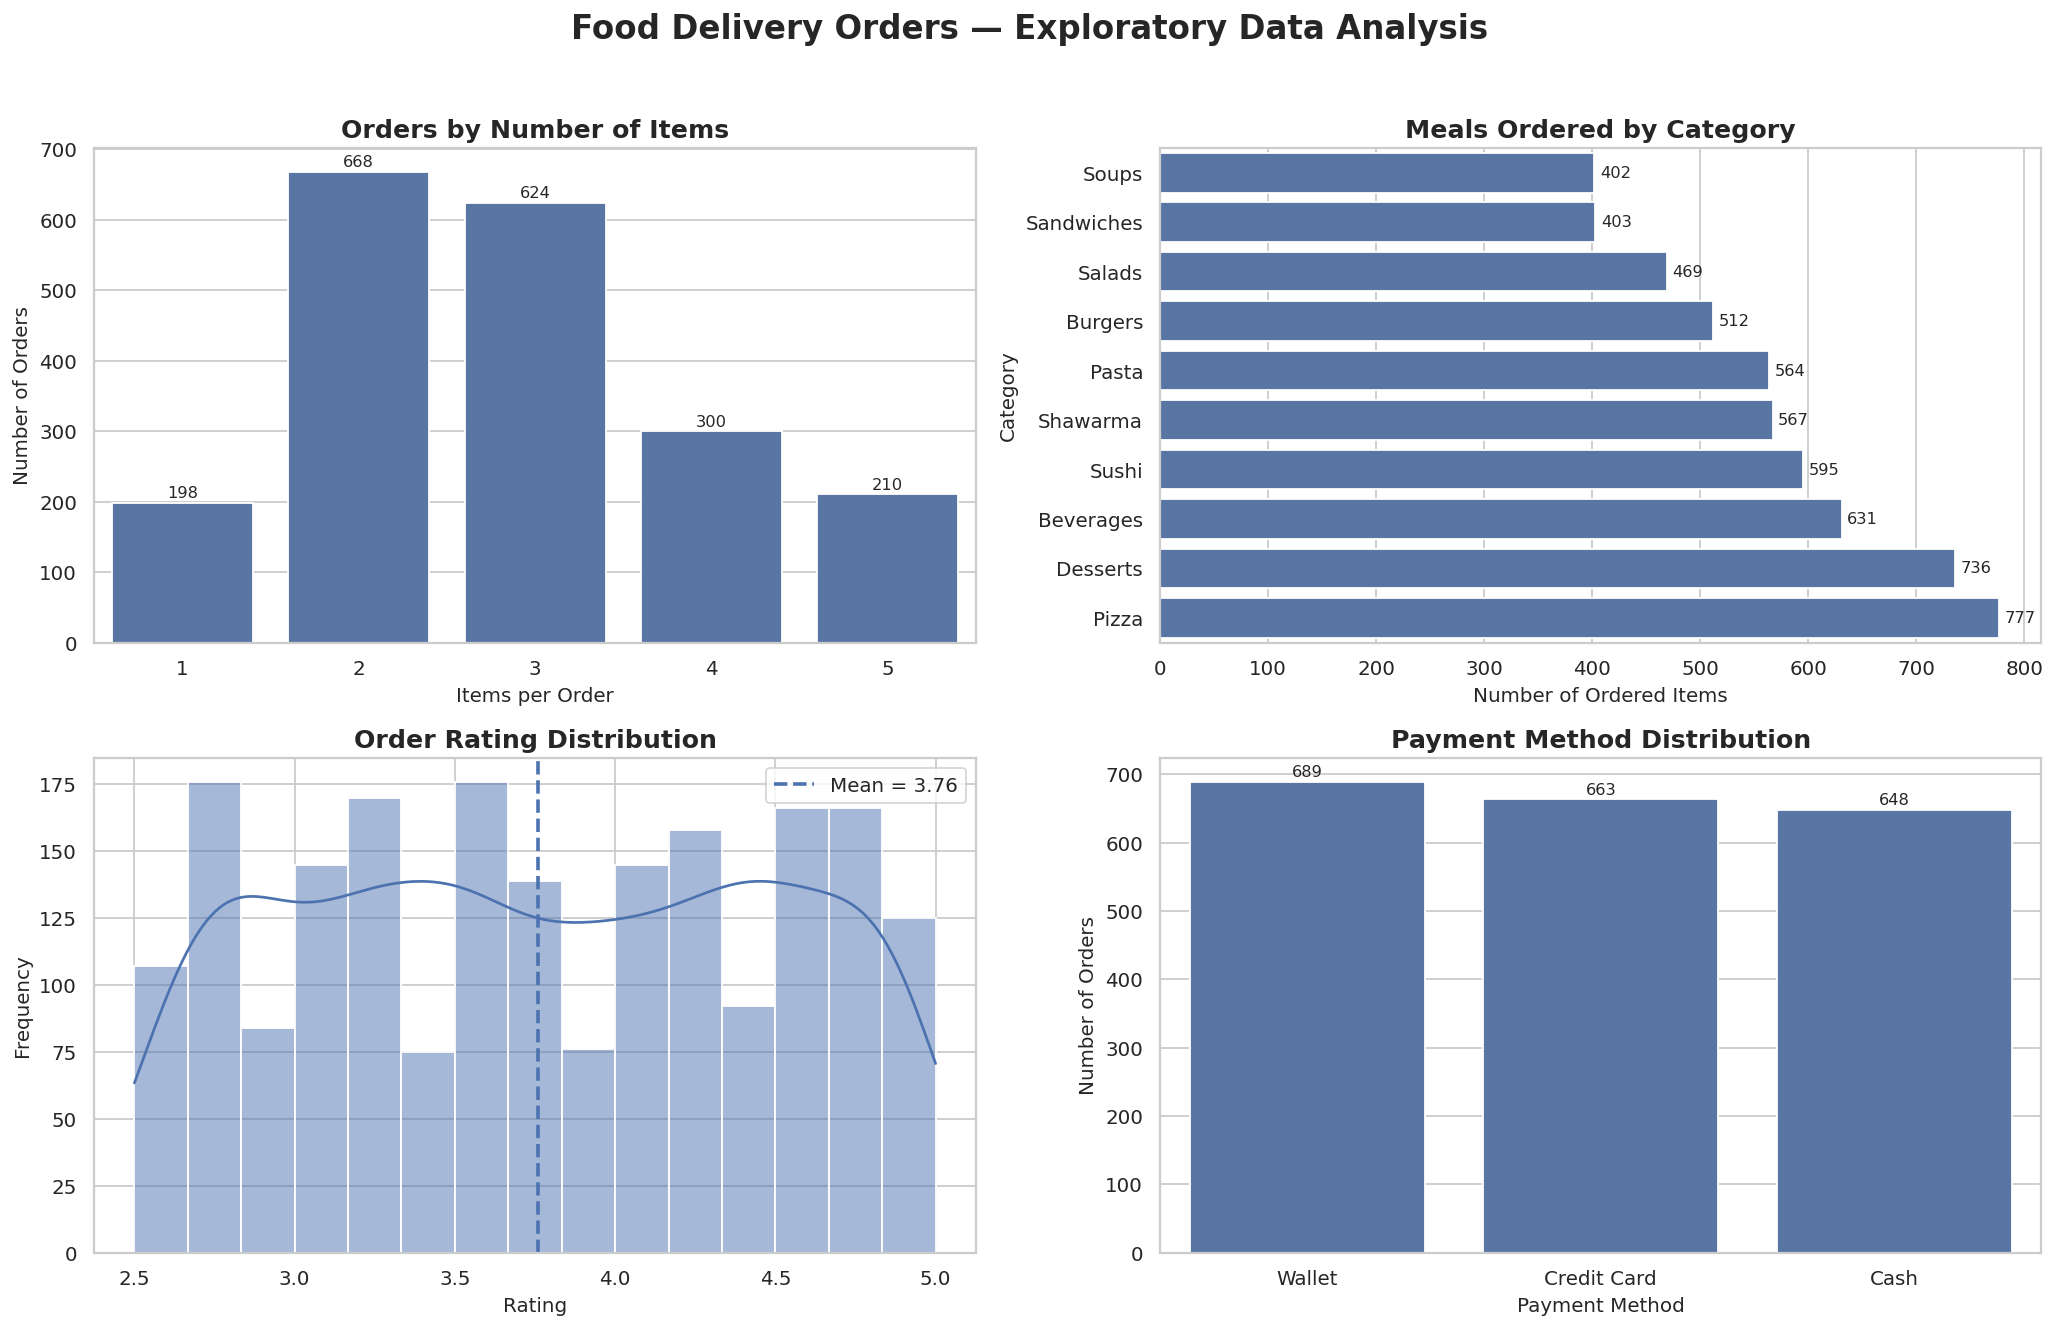

In [12]:
# ============================================================
# EDA Dashboard
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Food Delivery Orders — Exploratory Data Analysis", fontsize=18, fontweight="bold", y=1.02)

# 1) Orders by number of items
order_sizes = transactions_df["n_items"].value_counts().sort_index()
sns.barplot(x=order_sizes.index, y=order_sizes.values, ax=axes[0, 0])
axes[0, 0].set_title("Orders by Number of Items")
axes[0, 0].set_xlabel("Items per Order")
axes[0, 0].set_ylabel("Number of Orders")
add_bar_labels(axes[0, 0], "vertical")

# 2) Meals ordered by category
category_counts = pd.Series(split_items(transactions_df["item_categories"])).value_counts().sort_values()
sns.barplot(x=category_counts.values, y=category_counts.index, ax=axes[0, 1])
axes[0, 1].set_title("Meals Ordered by Category")
axes[0, 1].set_xlabel("Number of Ordered Items")
axes[0, 1].set_ylabel("Category")
add_bar_labels(axes[0, 1], "horizontal", padding=5)

# 3) Order rating distribution
sns.histplot(transactions_df["order_rating"], bins=15, kde=True, ax=axes[1, 0])
mean_rating = transactions_df["order_rating"].mean()
axes[1, 0].axvline(mean_rating, linestyle="--", linewidth=2, label=f"Mean = {mean_rating:.2f}")
axes[1, 0].set_title("Order Rating Distribution")
axes[1, 0].set_xlabel("Rating")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].legend()

# 4) Payment method distribution
payment_counts = transactions_df["payment_method"].value_counts()
sns.barplot(x=payment_counts.index, y=payment_counts.values, ax=axes[1, 1])
axes[1, 1].set_title("Payment Method Distribution")
axes[1, 1].set_xlabel("Payment Method")
axes[1, 1].set_ylabel("Number of Orders")
add_bar_labels(axes[1, 1], "vertical")

plt.tight_layout()
save_figure("01_eda_dashboard.png")
plt.show()

In [13]:
print("Key EDA Insights:")
print(f"- Most orders contain {order_sizes.idxmax()} items, with {order_sizes.max()} orders.")
print(f"- The most ordered category is '{category_counts.idxmax()}' with {category_counts.max()} ordered items.")
print(f"- The average order rating is {mean_rating:.2f}/5, indicating generally moderate-to-positive feedback.")
print(f"- The most used payment method is '{payment_counts.idxmax()}'.")

Key EDA Insights:
- Most orders contain 2 items, with 668 orders.
- The most ordered category is 'Pizza' with 777 ordered items.
- The average order rating is 3.76/5, indicating generally moderate-to-positive feedback.
- The most used payment method is 'Wallet'.


✅ Saved: output\figures\02_top15_ordered_meals.png


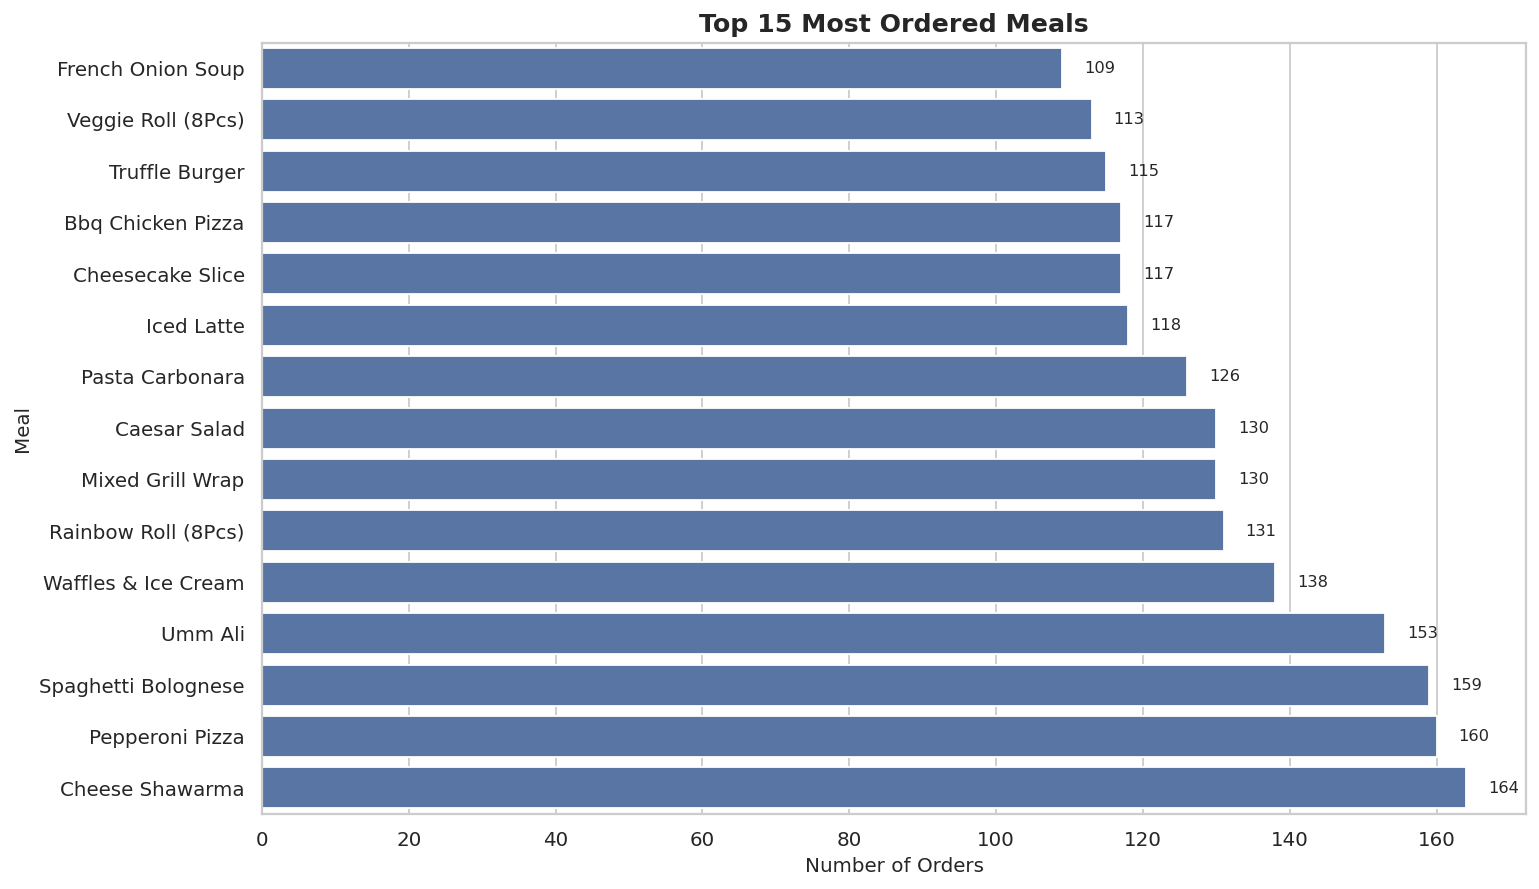

,Meal,count
0,Cheese Shawarma,164
1,Pepperoni Pizza,160
2,Spaghetti Bolognese,159
3,Umm Ali,153
4,Waffles & Ice Cream,138
5,Rainbow Roll (8Pcs),131
6,Caesar Salad,130
7,Mixed Grill Wrap,130
8,Pasta Carbonara,126
9,Iced Latte,118


In [14]:
# ============================================================
# Popular Meals Analysis
# ============================================================

meal_counts = pd.Series(split_items(transactions_df["item_names"])).value_counts()
top_meals = meal_counts.head(15).sort_values()

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=top_meals.values, y=top_meals.index)
ax.set_title("Top 15 Most Ordered Meals")
ax.set_xlabel("Number of Orders")
ax.set_ylabel("Meal")

add_bar_labels(ax, "horizontal", padding=3)

plt.tight_layout()
save_figure("02_top15_ordered_meals.png")
plt.show()

display(meal_counts.head(15).reset_index().rename(columns={"index": "Meal", 0: "Order Count"}))

✅ Saved: output\figures\04_temporal_patterns.png


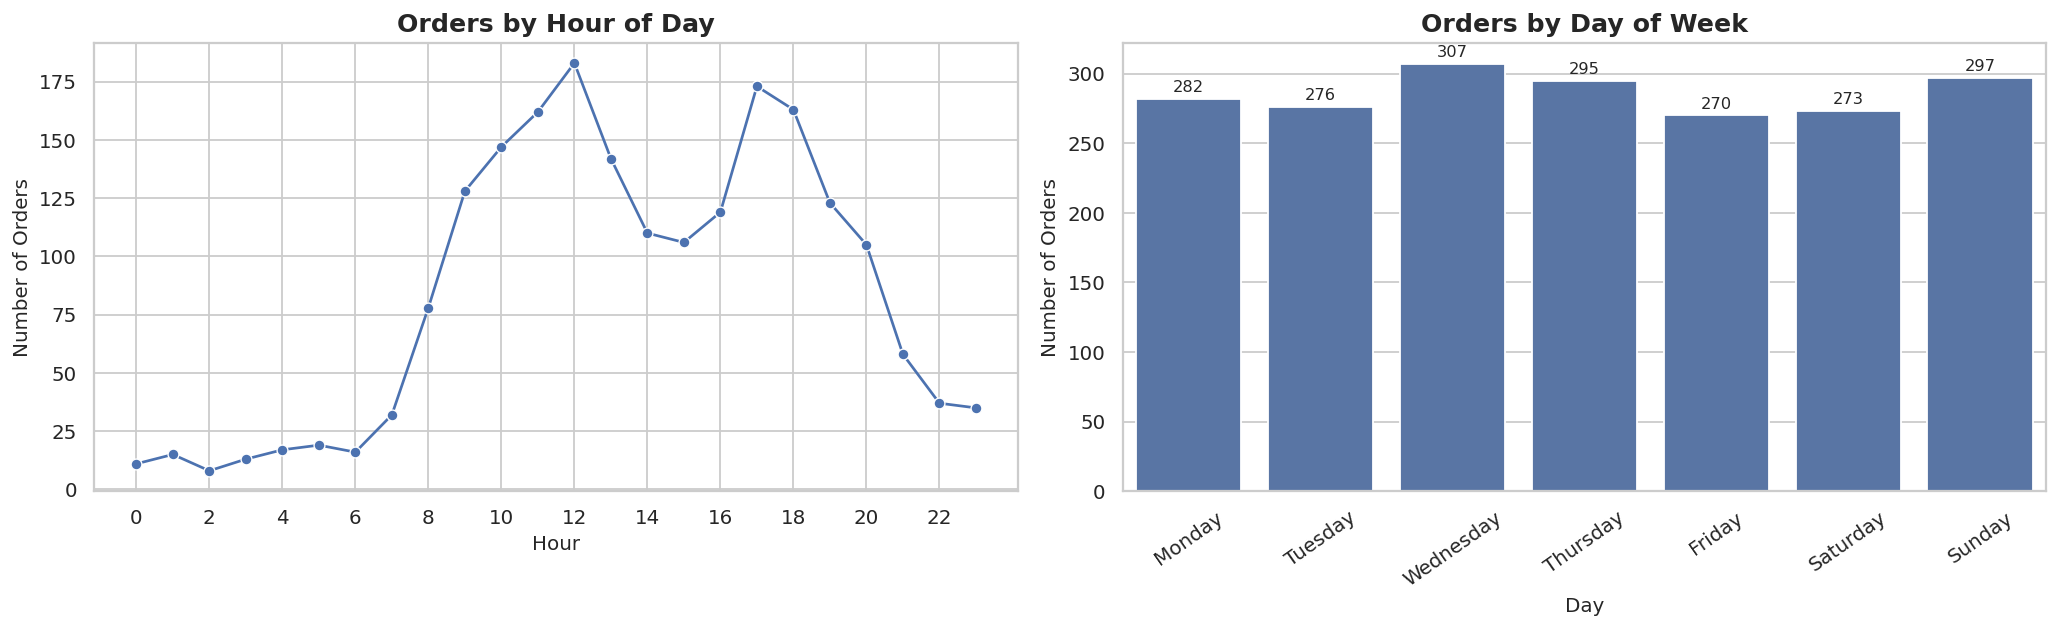

In [15]:
# ============================================================
# Temporal Ordering Patterns
# ============================================================

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Orders by hour
hour_counts = transactions_df["order_hour"].value_counts().sort_index()
sns.lineplot(x=hour_counts.index, y=hour_counts.values, marker="o", ax=axes[0])
axes[0].set_title("Orders by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Number of Orders")
axes[0].set_xticks(range(0, 24, 2))

# Orders by day
day_counts = transactions_df["order_day"].value_counts().reindex(day_order)
sns.barplot(x=day_counts.index, y=day_counts.values, ax=axes[1])
axes[1].set_title("Orders by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Number of Orders")
axes[1].tick_params(axis="x", rotation=35)
add_bar_labels(axes[1], "vertical")

plt.tight_layout()
save_figure("04_temporal_patterns.png")
plt.show()

In [19]:
# ============================================================
# Association Rules — Generate from Transactions
# ============================================================

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

transactions = transactions_df["item_names"].apply(
    lambda x: [item.strip() for item in str(x).split(",") if item.strip()]
).tolist()

print("Number of transactions:", len(transactions))
print("Example transaction:", transactions[0])

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
encoded_df = pd.DataFrame(te_array, columns=te.columns_)

print("Encoded matrix shape:", encoded_df.shape)

frequent_itemsets = fpgrowth(
    encoded_df,
    min_support=0.001,
    use_colnames=True
)

print("Frequent itemsets found:", len(frequent_itemsets))

rules_df = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0
)

rules_df = rules_df[
    (rules_df["support"] >= 0.001) &
    (rules_df["confidence"] >= 0.10) &
    (rules_df["lift"] >= 1.0)
].copy()

rules_df["antecedents_str"] = rules_df["antecedents"].apply(lambda x: ", ".join(list(x)))
rules_df["consequents_str"] = rules_df["consequents"].apply(lambda x: ", ".join(list(x)))
rules_df["rule"] = rules_df["antecedents_str"] + " → " + rules_df["consequents_str"]

rules_df = rules_df.sort_values(
    ["lift", "confidence", "support"],
    ascending=False
).reset_index(drop=True)

rules_df.to_csv(ASSOCIATION_RULES_PATH, index=False)
rules_df.head(20).to_csv(
    os.path.join(PROCESSED_DIR, "top20_association_rules.csv"),
    index=False
)

association_rules_df = rules_df.copy()

print("✅ Association rules generated and saved")
print("Rules shape:", rules_df.shape)

display(rules_df[["rule", "support", "confidence", "lift"]].head(15))

Number of transactions: 2000
Example transaction: ['Veggie Supreme Pizza', 'Umm Ali']
Encoded matrix shape: (2000, 70)
Frequent itemsets found: 1722
✅ Association rules generated and saved
Rules shape: (620, 17)


,rule,support,confidence,lift
0,"Truffle Burger, Club Sandwich → Spaghetti Bolo...",0.001,0.500000,200.000000
1,"Spaghetti Bolognese, Iced Latte → Truffle Burg...",0.001,0.400000,200.000000
2,"Club Sandwich, Iced Latte → Truffle Burger, Sp...",0.001,0.666667,148.148148
3,"Truffle Burger, Spaghetti Bolognese → Club San...",0.001,0.222222,148.148148
4,"Club Sandwich, Spaghetti Bolognese → Truffle B...",0.001,0.400000,100.000000
5,"Truffle Burger, Iced Latte → Club Sandwich, Sp...",0.001,0.250000,100.000000
6,"Truffle Burger, Club Sandwich → Cheese Shawarm...",0.001,0.500000,90.909091
7,"Cheese Shawarma, Spaghetti Bolognese → Truffle...",0.001,0.181818,90.909091
8,"Club Sandwich, Cheese Shawarma → Truffle Burge...",0.001,0.400000,88.888889
9,"Truffle Burger, Spaghetti Bolognese → Club San...",0.001,0.222222,88.888889


In [20]:
# ============================================================
# Association Rules — Load Results
# ============================================================

if os.path.exists(ASSOCIATION_RULES_PATH):
    association_rules_df = pd.read_csv(ASSOCIATION_RULES_PATH)
    print("✅ Association rules loaded")
    print("Shape:", association_rules_df.shape)
    display(association_rules_df.head())
else:
    association_rules_df = None
    print("❌ association_rules.csv not found.")
    print("Expected path:", ASSOCIATION_RULES_PATH)
    print("Ask Person 2 to export the rules as association_rules.csv.")

✅ Association rules loaded
Shape: (620, 17)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedents_str,consequents_str,rule
0,"frozenset({'Truffle Burger', 'Club Sandwich'})","frozenset({'Spaghetti Bolognese', 'Iced Latte'})",0.0020,0.0025,0.001,0.500000,200.000000,1.0,0.000995,1.995000,0.996994,0.285714,0.498747,0.450000,"Truffle Burger, Club Sandwich","Spaghetti Bolognese, Iced Latte","Truffle Burger, Club Sandwich → Spaghetti Bolo..."
1,"frozenset({'Spaghetti Bolognese', 'Iced Latte'})","frozenset({'Truffle Burger', 'Club Sandwich'})",0.0025,0.0020,0.001,0.400000,200.000000,1.0,0.000995,1.663333,0.997494,0.285714,0.398798,0.450000,"Spaghetti Bolognese, Iced Latte","Truffle Burger, Club Sandwich","Spaghetti Bolognese, Iced Latte → Truffle Burg..."
2,"frozenset({'Club Sandwich', 'Iced Latte'})","frozenset({'Truffle Burger', 'Spaghetti Bologn...",0.0015,0.0045,0.001,0.666667,148.148148,1.0,0.000993,2.986500,0.994742,0.200000,0.665160,0.444444,"Club Sandwich, Iced Latte","Truffle Burger, Spaghetti Bolognese","Club Sandwich, Iced Latte → Truffle Burger, Sp..."
3,"frozenset({'Truffle Burger', 'Spaghetti Bologn...","frozenset({'Club Sandwich', 'Iced Latte'})",0.0045,0.0015,0.001,0.222222,148.148148,1.0,0.000993,1.283786,0.997740,0.200000,0.221054,0.444444,"Truffle Burger, Spaghetti Bolognese","Club Sandwich, Iced Latte","Truffle Burger, Spaghetti Bolognese → Club San..."
4,"frozenset({'Club Sandwich', 'Spaghetti Bologne...","frozenset({'Truffle Burger', 'Iced Latte'})",0.0025,0.0040,0.001,0.400000,100.000000,1.0,0.000990,1.660000,0.992481,0.181818,0.397590,0.325000,"Club Sandwich, Spaghetti Bolognese","Truffle Burger, Iced Latte","Club Sandwich, Spaghetti Bolognese → Truffle B..."


In [21]:
# ============================================================
# Association Rules — Prepare Labels
# ============================================================

if association_rules_df is not None:
    
    rules_df = association_rules_df.copy()

    # Handle different possible column names
    if "rule" not in rules_df.columns:
        if "antecedents_str" in rules_df.columns and "consequents_str" in rules_df.columns:
            rules_df["rule"] = rules_df["antecedents_str"] + " → " + rules_df["consequents_str"]
        elif "Left Hand Side" in rules_df.columns and "Right Hand Side" in rules_df.columns:
            rules_df["rule"] = rules_df["Left Hand Side"].astype(str) + " → " + rules_df["Right Hand Side"].astype(str)
        elif "antecedents" in rules_df.columns and "consequents" in rules_df.columns:
            rules_df["rule"] = rules_df["antecedents"].astype(str) + " → " + rules_df["consequents"].astype(str)

    # Standardize metric names if needed
    rename_map = {
        "Support": "support",
        "Confidence": "confidence",
        "Lift": "lift"
    }
    rules_df = rules_df.rename(columns=rename_map)

    # Keep valid rows
    rules_df = rules_df.dropna(subset=["support", "confidence", "lift", "rule"])
    rules_df = rules_df.sort_values("lift", ascending=False).reset_index(drop=True)

    print("✅ Rules prepared")
    display(rules_df[["rule", "support", "confidence", "lift"]].head(10))

✅ Rules prepared


,rule,support,confidence,lift
0,"Truffle Burger, Club Sandwich → Spaghetti Bolo...",0.001,0.500000,200.000000
1,"Spaghetti Bolognese, Iced Latte → Truffle Burg...",0.001,0.400000,200.000000
2,"Club Sandwich, Iced Latte → Truffle Burger, Sp...",0.001,0.666667,148.148148
3,"Truffle Burger, Spaghetti Bolognese → Club San...",0.001,0.222222,148.148148
4,"Club Sandwich, Spaghetti Bolognese → Truffle B...",0.001,0.400000,100.000000
5,"Truffle Burger, Iced Latte → Club Sandwich, Sp...",0.001,0.250000,100.000000
6,"Truffle Burger, Club Sandwich → Cheese Shawarm...",0.001,0.500000,90.909091
7,"Cheese Shawarma, Spaghetti Bolognese → Truffle...",0.001,0.181818,90.909091
8,"Club Sandwich, Cheese Shawarma → Truffle Burge...",0.001,0.400000,88.888889
9,"Truffle Burger, Spaghetti Bolognese → Club San...",0.001,0.222222,88.888889


✅ Saved: output\figures\05_top10_association_rules_by_lift.png


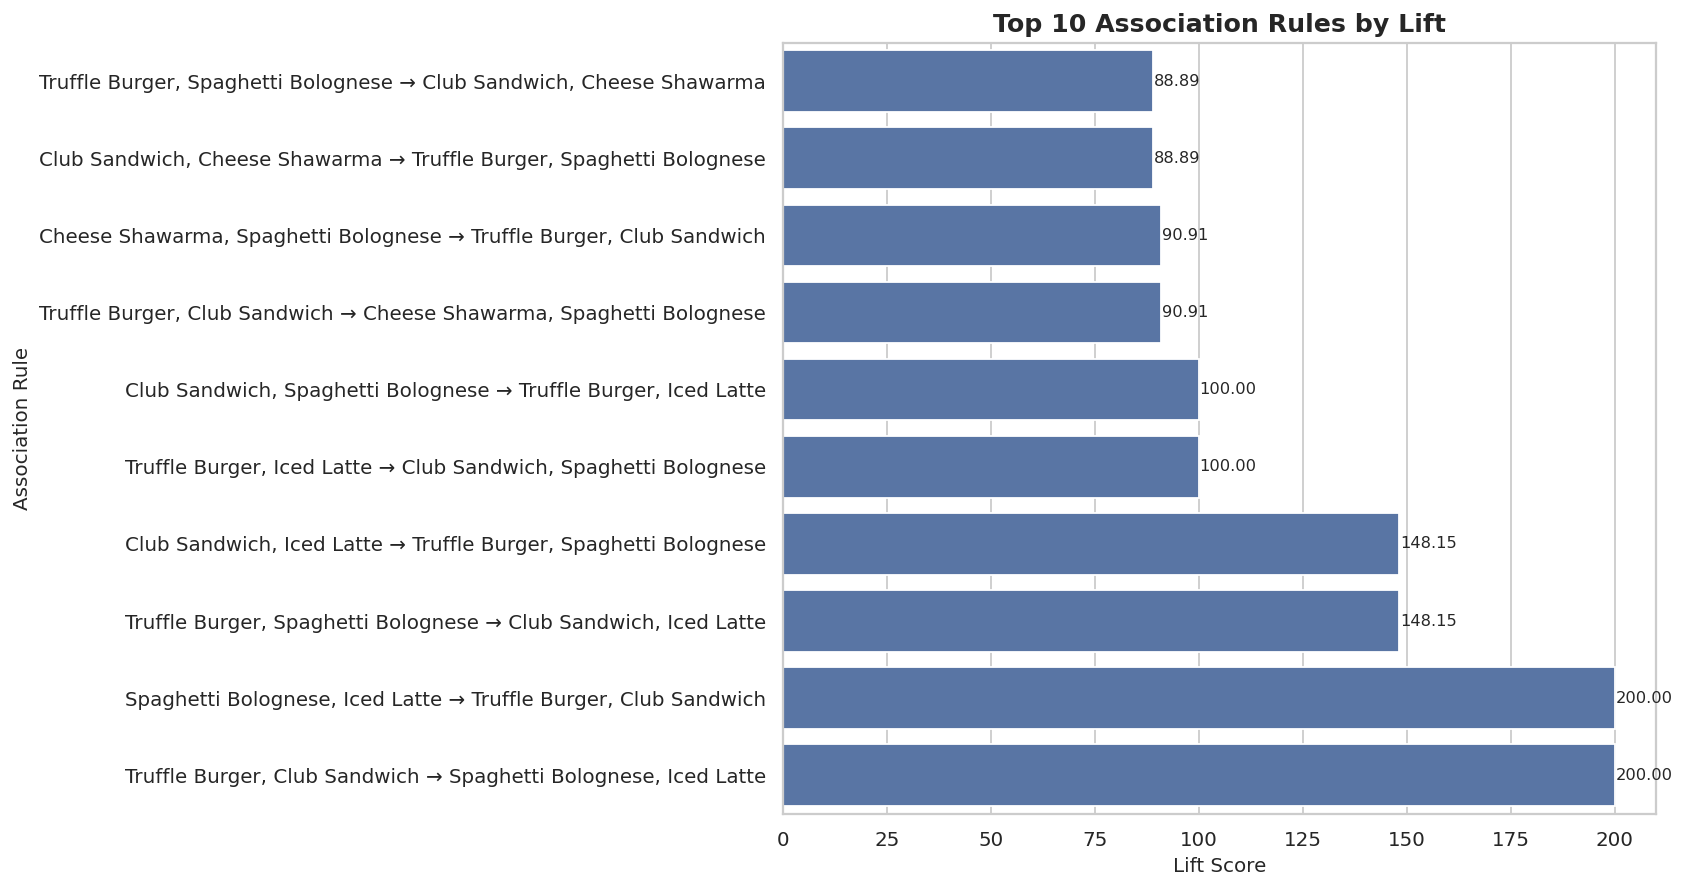

In [22]:
# ============================================================
# Association Rules — Top 10 by Lift
# ============================================================

top_rules = rules_df.head(10).copy()
top_rules = top_rules.sort_values("lift")

plt.figure(figsize=(13, 7))

ax = sns.barplot(
    data=top_rules,
    x="lift",
    y="rule"
)

ax.set_title("Top 10 Association Rules by Lift")
ax.set_xlabel("Lift Score")
ax.set_ylabel("Association Rule")

for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
save_figure("05_top10_association_rules_by_lift.png")
plt.show()

✅ Saved: output\figures\06_association_rules_scatter.png


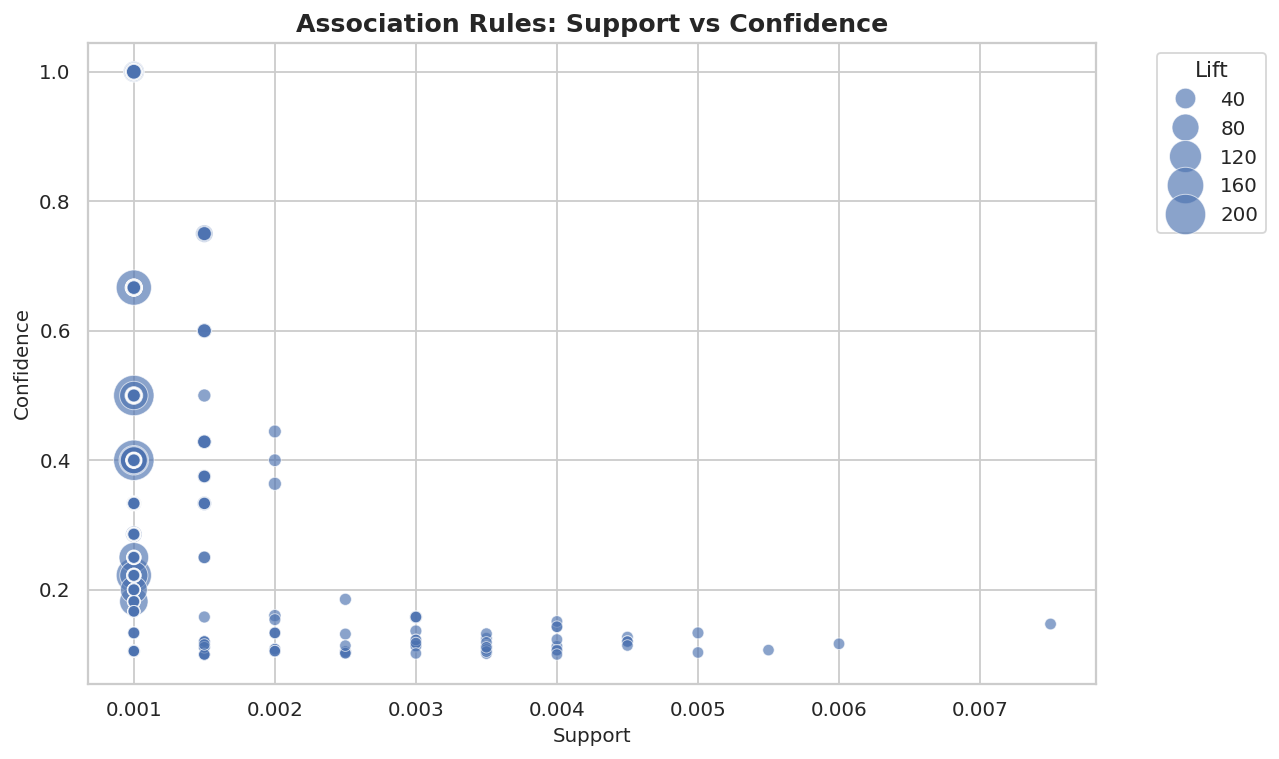

In [23]:
# ============================================================
# Association Rules — Support vs Confidence
# ============================================================

plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=rules_df,
    x="support",
    y="confidence",
    size="lift",
    sizes=(40, 500),
    alpha=0.65,
    legend=True
)

ax.set_title("Association Rules: Support vs Confidence")
ax.set_xlabel("Support")
ax.set_ylabel("Confidence")

plt.legend(title="Lift", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
save_figure("06_association_rules_scatter.png")
plt.show()

✅ Saved: output\figures\07_association_rules_network.png


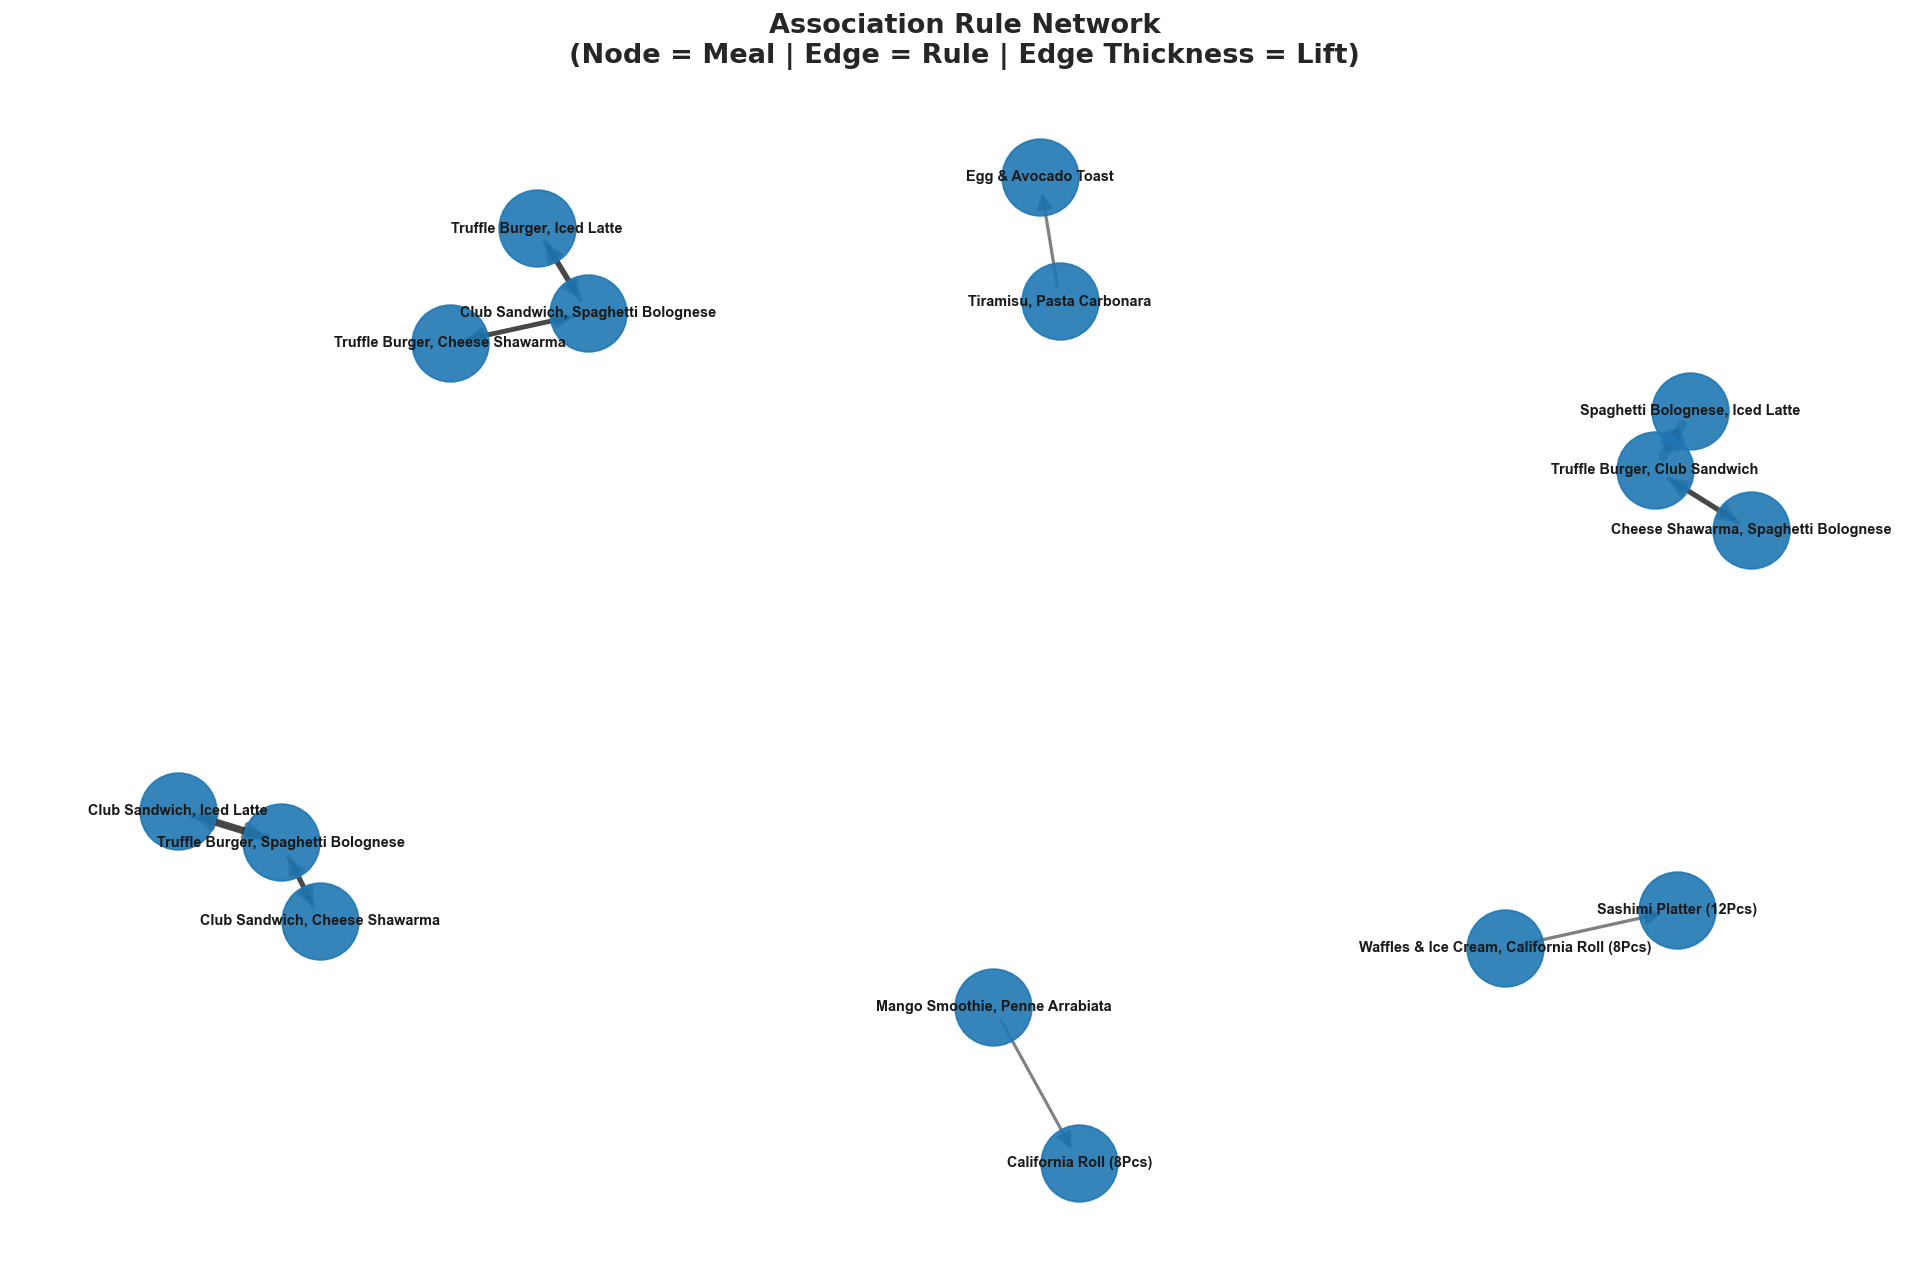

In [24]:
# ============================================================
# Association Rules — Network Graph
# ============================================================

network_rules = rules_df.head(15).copy()

G_rules = nx.DiGraph()

for _, row in network_rules.iterrows():
    lhs = row["antecedents_str"]
    rhs = row["consequents_str"]

    G_rules.add_node(lhs)
    G_rules.add_node(rhs)
    G_rules.add_edge(
        lhs,
        rhs,
        weight=row["lift"],
        confidence=row["confidence"],
        support=row["support"]
    )

plt.figure(figsize=(15, 10))

pos = nx.spring_layout(G_rules, seed=42, k=1.7)

edge_weights = [G_rules[u][v]["weight"] for u, v in G_rules.edges()]
max_weight = max(edge_weights) if edge_weights else 1
edge_widths = [1 + 4 * (w / max_weight) for w in edge_weights]

nx.draw_networkx_nodes(
    G_rules,
    pos,
    node_size=1800,
    alpha=0.9
)

nx.draw_networkx_edges(
    G_rules,
    pos,
    width=edge_widths,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=18,
    alpha=0.55
)

nx.draw_networkx_labels(
    G_rules,
    pos,
    font_size=8,
    font_weight="bold"
)

plt.title(
    "Association Rule Network\n(Node = Meal | Edge = Rule | Edge Thickness = Lift)",
    fontsize=15,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()
save_figure("07_association_rules_network.png")
plt.show()

In [28]:
# ============================================================
# Association Rules — Report Insights
# ============================================================

best_lift_rule = rules_df.iloc[0]
best_reliable_rule = reliable_rules.iloc[0]

print("Association Rules Insights:")
print(f"- Total association rules analyzed: {len(rules_df):,}")
print()
print(f"- Highest-lift rule: {best_lift_rule['rule']}")
print(
    f"  Lift: {best_lift_rule['lift']:.2f}, "
    f"Confidence: {best_lift_rule['confidence']:.2f}, "
    f"Support: {best_lift_rule['support']:.4f}"
)
print()
print(f"- Most reliable rule: {best_reliable_rule['rule']}")
print(
    f"  Reliability Score: {best_reliable_rule['reliability_score']:.4f}, "
    f"Lift: {best_reliable_rule['lift']:.2f}, "
    f"Confidence: {best_reliable_rule['confidence']:.2f}, "
    f"Support: {best_reliable_rule['support']:.4f}"
)
print()
print("Interpretation:")
print(
    "High-lift rules show meal combinations that occur together more often than expected by chance. "
    "However, some high-lift rules have low support, meaning they appeared in only a small number of orders. "
    "For this reason, a reliability score was also calculated using lift, confidence, and support to identify "
    "rules that are more useful for recommendation and bundle design."
)

Association Rules Insights:
- Total association rules analyzed: 620

- Highest-lift rule: Truffle Burger, Club Sandwich → Spaghetti Bolognese, Iced Latte
  Lift: 200.00, Confidence: 0.50, Support: 0.0010

- Most reliable rule: Truffle Burger, Club Sandwich → Spaghetti Bolognese, Iced Latte
  Reliability Score: 0.1000, Lift: 200.00, Confidence: 0.50, Support: 0.0010

Interpretation:
High-lift rules show meal combinations that occur together more often than expected by chance. However, some high-lift rules have low support, meaning they appeared in only a small number of orders. For this reason, a reliability score was also calculated using lift, confidence, and support to identify rules that are more useful for recommendation and bundle design.


In [26]:
# ============================================================
# Association Rules — Reliability Score
# ============================================================

rules_df["reliability_score"] = (
    rules_df["lift"] *
    rules_df["confidence"] *
    rules_df["support"]
)

reliable_rules = rules_df.sort_values(
    ["reliability_score", "lift", "confidence"],
    ascending=False
).reset_index(drop=True)

display(
    reliable_rules[
        ["rule", "support", "confidence", "lift", "reliability_score"]
    ].head(10)
)

,rule,support,confidence,lift,reliability_score
0,"Truffle Burger, Club Sandwich → Spaghetti Bolo...",0.001,0.500000,200.000000,0.100000
1,"Club Sandwich, Iced Latte → Truffle Burger, Sp...",0.001,0.666667,148.148148,0.098765
2,"Spaghetti Bolognese, Iced Latte → Truffle Burg...",0.001,0.400000,200.000000,0.080000
3,"Truffle Burger, Club Sandwich → Cheese Shawarm...",0.001,0.500000,90.909091,0.045455
4,"Waffles & Ice Cream, California Roll (8Pcs) → ...",0.001,1.000000,40.816327,0.040816
5,"Club Sandwich, Spaghetti Bolognese → Truffle B...",0.001,0.400000,100.000000,0.040000
6,"Tiramisu, Pasta Carbonara → Egg & Avocado Toast",0.001,1.000000,39.215686,0.039216
7,"Mango Smoothie, Penne Arrabiata → California R...",0.001,1.000000,35.714286,0.035714
8,"Sashimi Platter (12Pcs), Waffles & Ice Cream →...",0.001,1.000000,35.714286,0.035714
9,"Club Sandwich, Cheese Shawarma → Truffle Burge...",0.001,0.400000,88.888889,0.035556


✅ Saved: output\figures\08_top10_reliable_association_rules.png


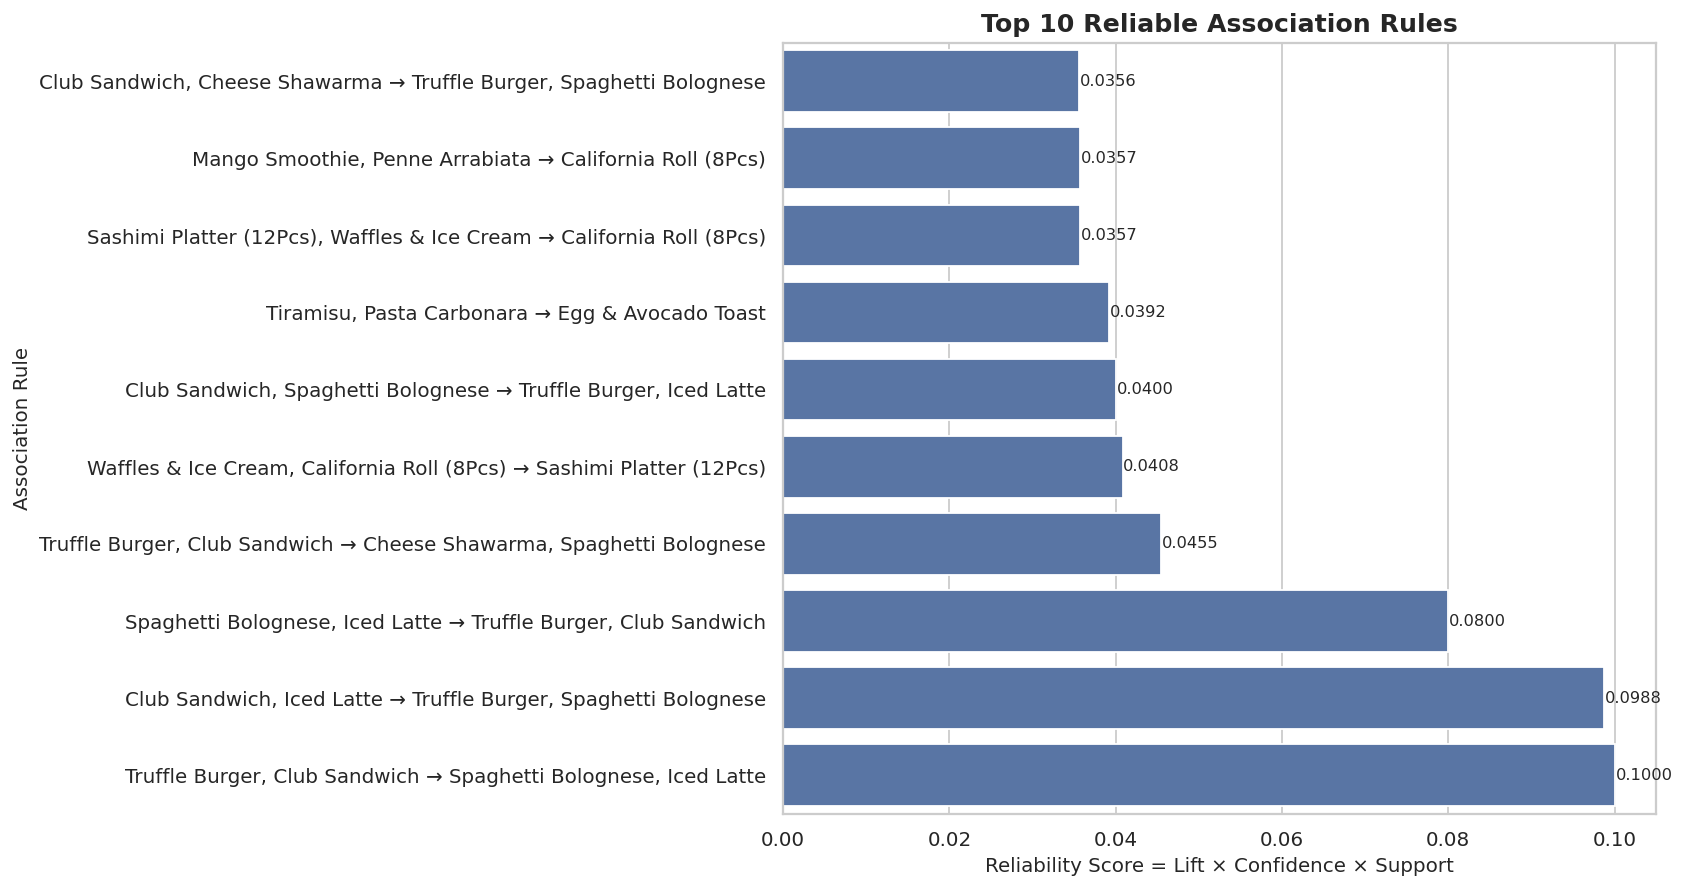

In [27]:
# ============================================================
# Association Rules — Top Reliable Rules
# ============================================================

top_reliable = reliable_rules.head(10).copy()
top_reliable = top_reliable.sort_values("reliability_score")

plt.figure(figsize=(13, 7))

ax = sns.barplot(
    data=top_reliable,
    x="reliability_score",
    y="rule"
)

ax.set_title("Top 10 Reliable Association Rules")
ax.set_xlabel("Reliability Score = Lift × Confidence × Support")
ax.set_ylabel("Association Rule")

for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width + 0.0001,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
save_figure("08_top10_reliable_association_rules.png")
plt.show()

In [29]:
# ============================================================
# PageRank — Build Co-ordering Graph
# ============================================================

# Build meal lookup from transactions
meal_lookup = {}

for _, row in transactions_df.iterrows():
    meal_ids = [x.strip() for x in str(row["items"]).split(",") if x.strip()]
    meal_names = [x.strip() for x in str(row["item_names"]).split(",") if x.strip()]
    meal_categories = [x.strip() for x in str(row["item_categories"]).split(",") if x.strip()]
    
    for i, meal_id in enumerate(meal_ids):
        if meal_id not in meal_lookup:
            meal_lookup[meal_id] = {
                "meal_name": meal_names[i] if i < len(meal_names) else meal_id,
                "category": meal_categories[i] if i < len(meal_categories) else "Unknown"
            }

# Create graph
G = nx.Graph()

# Add nodes
for meal_id, info in meal_lookup.items():
    G.add_node(
        meal_id,
        meal_name=info["meal_name"],
        category=info["category"]
    )

# Add weighted edges based on co-ordering
edge_counter = Counter()

for _, row in transactions_df.iterrows():
    meal_ids = [x.strip() for x in str(row["items"]).split(",") if x.strip()]
    
    if len(meal_ids) >= 2:
        for a, b in combinations(sorted(meal_ids), 2):
            edge_counter[(a, b)] += 1

for (a, b), weight in edge_counter.items():
    G.add_edge(a, b, weight=weight)

print("Co-ordering Graph Summary:")
print(f"- Nodes / Meals: {G.number_of_nodes():,}")
print(f"- Edges / Co-ordering pairs: {G.number_of_edges():,}")
print(f"- Average Degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
print(f"- Is Connected: {nx.is_connected(G)}")

Co-ordering Graph Summary:
- Nodes / Meals: 355
- Edges / Co-ordering pairs: 5,890
- Average Degree: 33.18
- Is Connected: True


In [30]:
# ============================================================
# PageRank — Calculate Influence Scores
# ============================================================

pagerank_scores = nx.pagerank(
    G,
    alpha=0.85,
    weight="weight",
    max_iter=200
)

pagerank_results = []

for meal_id, score in pagerank_scores.items():
    info = meal_lookup.get(meal_id, {})
    
    pagerank_results.append({
        "meal_id": meal_id,
        "meal_name": info.get("meal_name", meal_id),
        "category": info.get("category", "Unknown"),
        "pagerank_score": score,
        "degree": G.degree(meal_id),
        "weighted_degree": sum(edge_data["weight"] for _, _, edge_data in G.edges(meal_id, data=True))
    })

pagerank_df = pd.DataFrame(pagerank_results)
pagerank_df = pagerank_df.sort_values("pagerank_score", ascending=False).reset_index(drop=True)
pagerank_df["rank"] = pagerank_df.index + 1

pagerank_df.to_csv(PAGERANK_PATH, index=False)
pagerank_df.head(20).to_csv(
    os.path.join(PROCESSED_DIR, "top20_pagerank.csv"),
    index=False
)

print("✅ PageRank results calculated and saved")
print("PageRank shape:", pagerank_df.shape)

display(
    pagerank_df[
        ["rank", "meal_name", "category", "pagerank_score", "degree", "weighted_degree"]
    ].head(20)
)

✅ PageRank results calculated and saved
PageRank shape: (355, 7)


,rank,meal_name,category,pagerank_score,degree,weighted_degree
0,1,Mint Lemonade,Beverages,0.007816,94,111
1,2,Hawaiian Pizza,Pizza,0.007566,89,109
2,3,Iced Latte,Beverages,0.007473,94,108
3,4,Caesar Salad,Salads,0.006949,91,100
4,5,Waffles & Ice Cream,Desserts,0.006834,81,100
5,6,Egg & Avocado Toast,Sandwiches,0.006777,80,95
6,7,Cheese Shawarma,Shawarma,0.006733,78,97
7,8,Margherita Pizza,Pizza,0.006701,78,95
8,9,Mixed Grill Wrap,Shawarma,0.006608,81,94
9,10,Crème Brûlée,Desserts,0.006577,77,92


✅ Saved: output\figures\09_top20_pagerank_meals.png


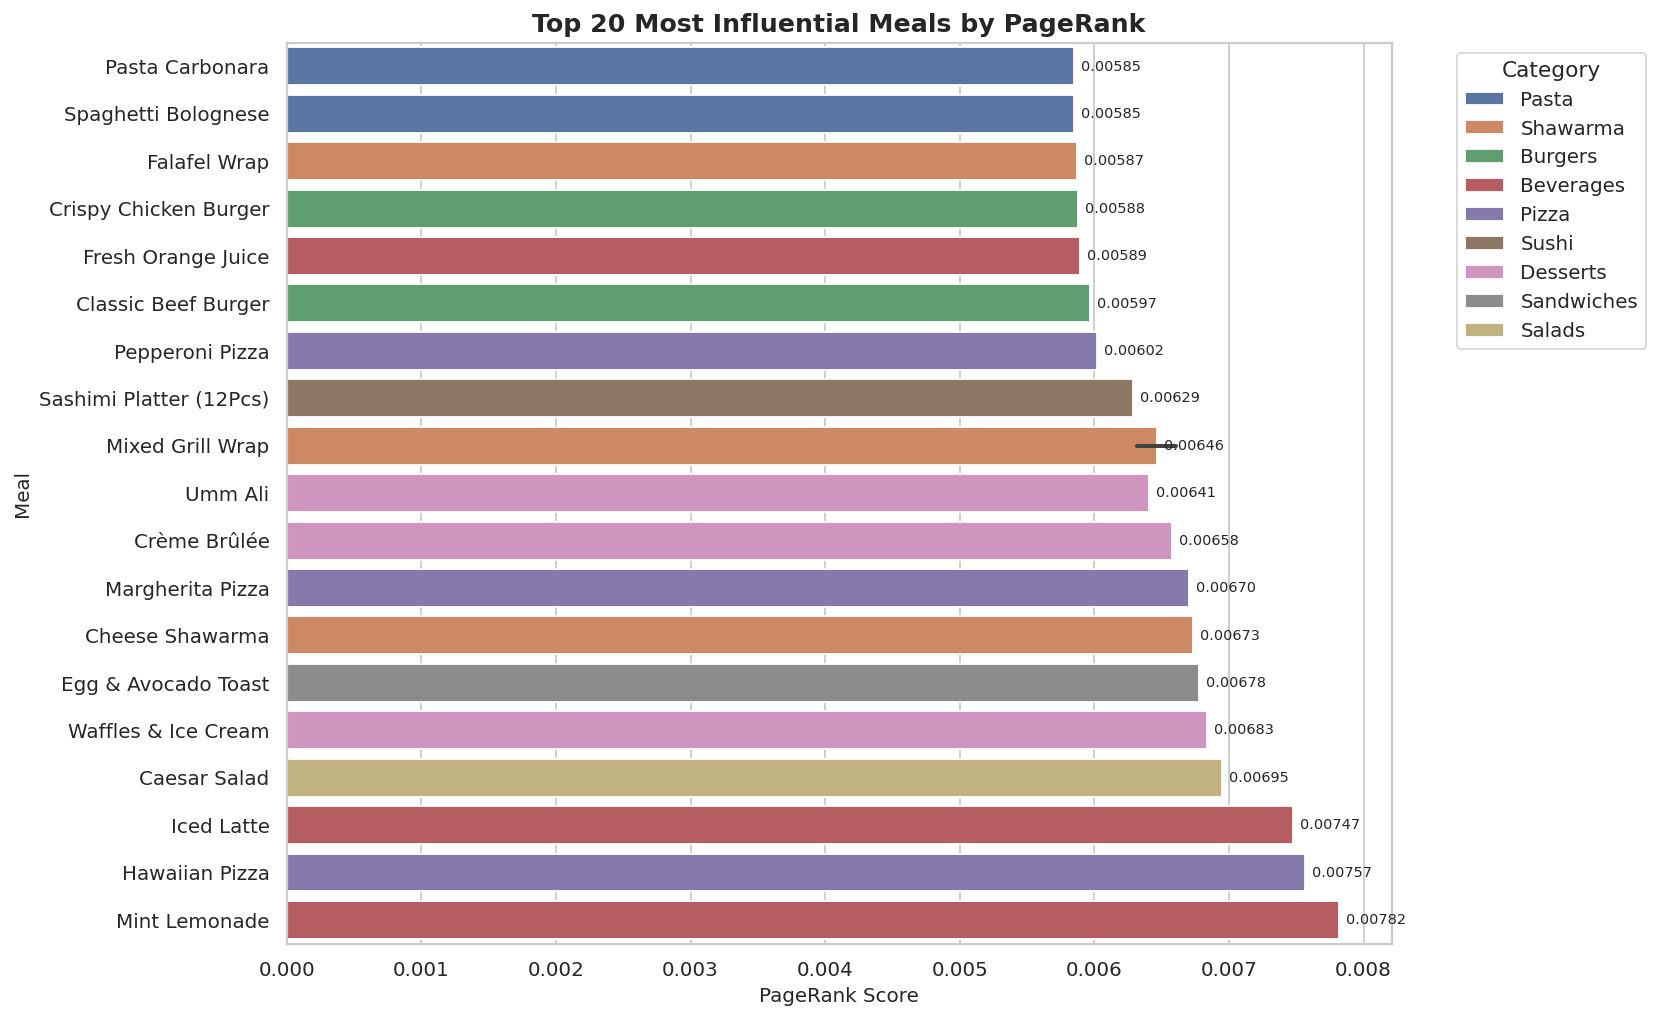

In [31]:
# ============================================================
# PageRank — Top 20 Influential Meals
# ============================================================

top20_pr = pagerank_df.head(20).copy()
top20_pr = top20_pr.sort_values("pagerank_score")

plt.figure(figsize=(13, 8))

ax = sns.barplot(
    data=top20_pr,
    x="pagerank_score",
    y="meal_name",
    hue="category",
    dodge=False
)

ax.set_title("Top 20 Most Influential Meals by PageRank")
ax.set_xlabel("PageRank Score")
ax.set_ylabel("Meal")

for bar in ax.patches:
    width = bar.get_width()
    if width > 0:
        ax.text(
            width + 0.00005,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.5f}",
            va="center",
            fontsize=8
        )

ax.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
save_figure("09_top20_pagerank_meals.png")
plt.show()

✅ Saved: output\figures\10_pagerank_by_category.png


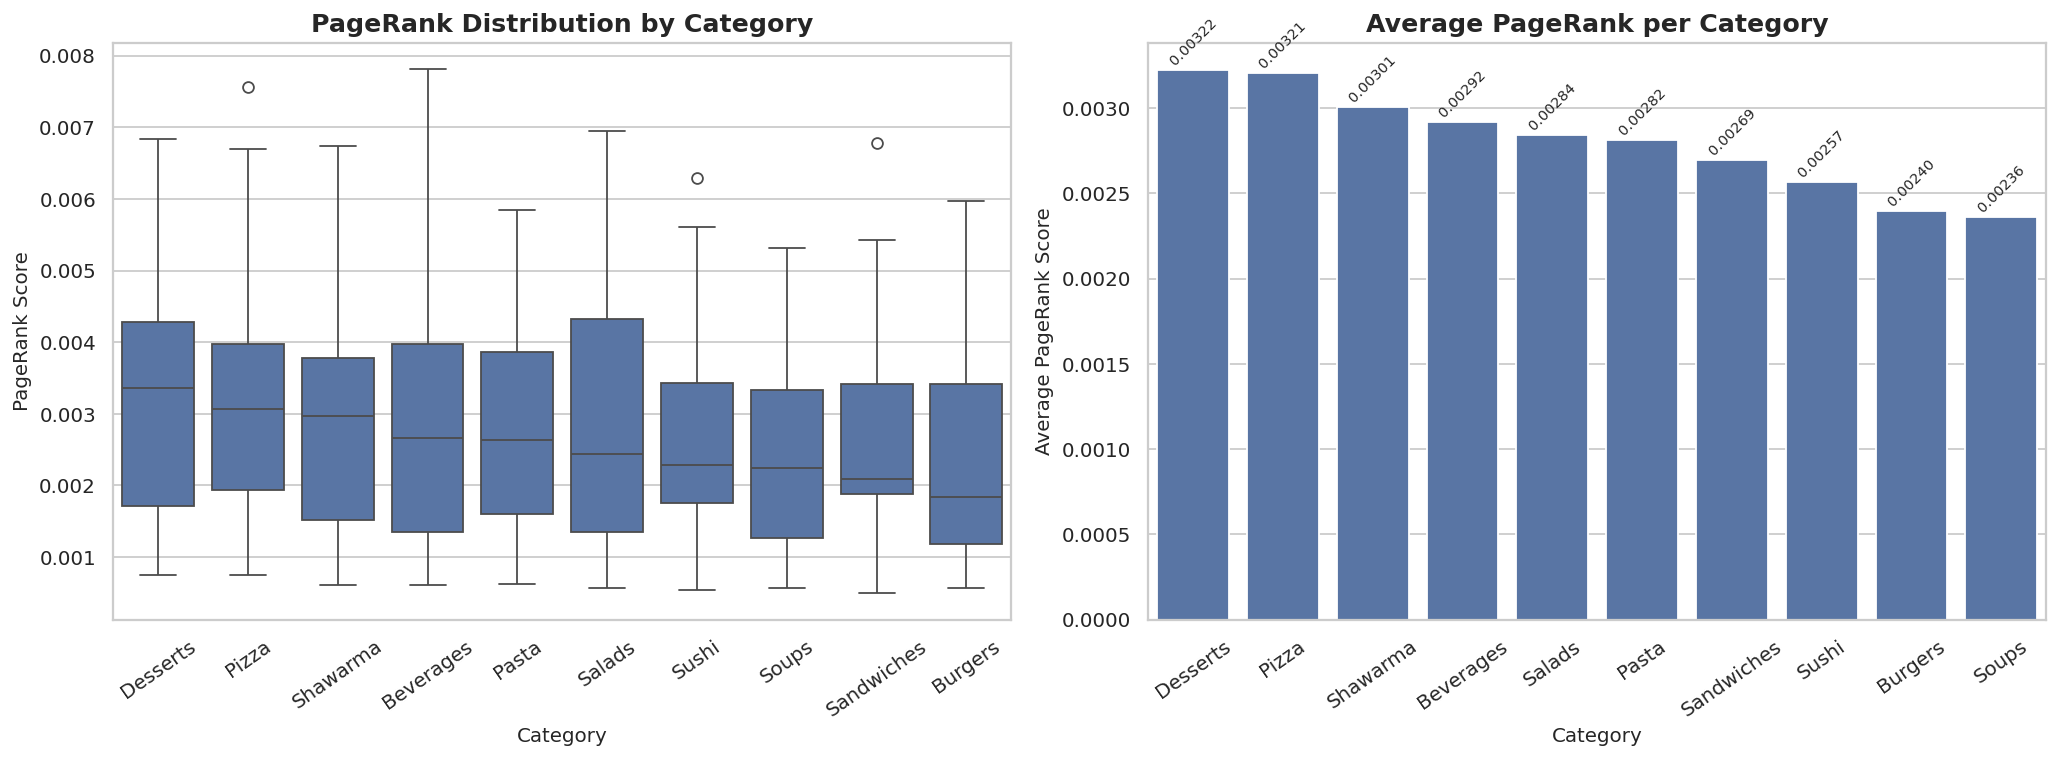

In [32]:
# ============================================================
# PageRank — Category-Level Analysis
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1) PageRank distribution by category
category_order = (
    pagerank_df
    .groupby("category")["pagerank_score"]
    .median()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=pagerank_df,
    x="category",
    y="pagerank_score",
    order=category_order,
    ax=axes[0]
)

axes[0].set_title("PageRank Distribution by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("PageRank Score")
axes[0].tick_params(axis="x", rotation=35)

# 2) Average PageRank by category
avg_category_pr = (
    pagerank_df
    .groupby("category")["pagerank_score"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=avg_category_pr.index,
    y=avg_category_pr.values,
    ax=axes[1]
)

axes[1].set_title("Average PageRank per Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Average PageRank Score")
axes[1].tick_params(axis="x", rotation=35)

for i, value in enumerate(avg_category_pr.values):
    axes[1].text(
        i,
        value + 0.00003,
        f"{value:.5f}",
        ha="center",
        fontsize=8,
        rotation=45
    )

plt.tight_layout()
save_figure("10_pagerank_by_category.png")
plt.show()

✅ Saved: output\figures\11_pagerank_vs_degree.png


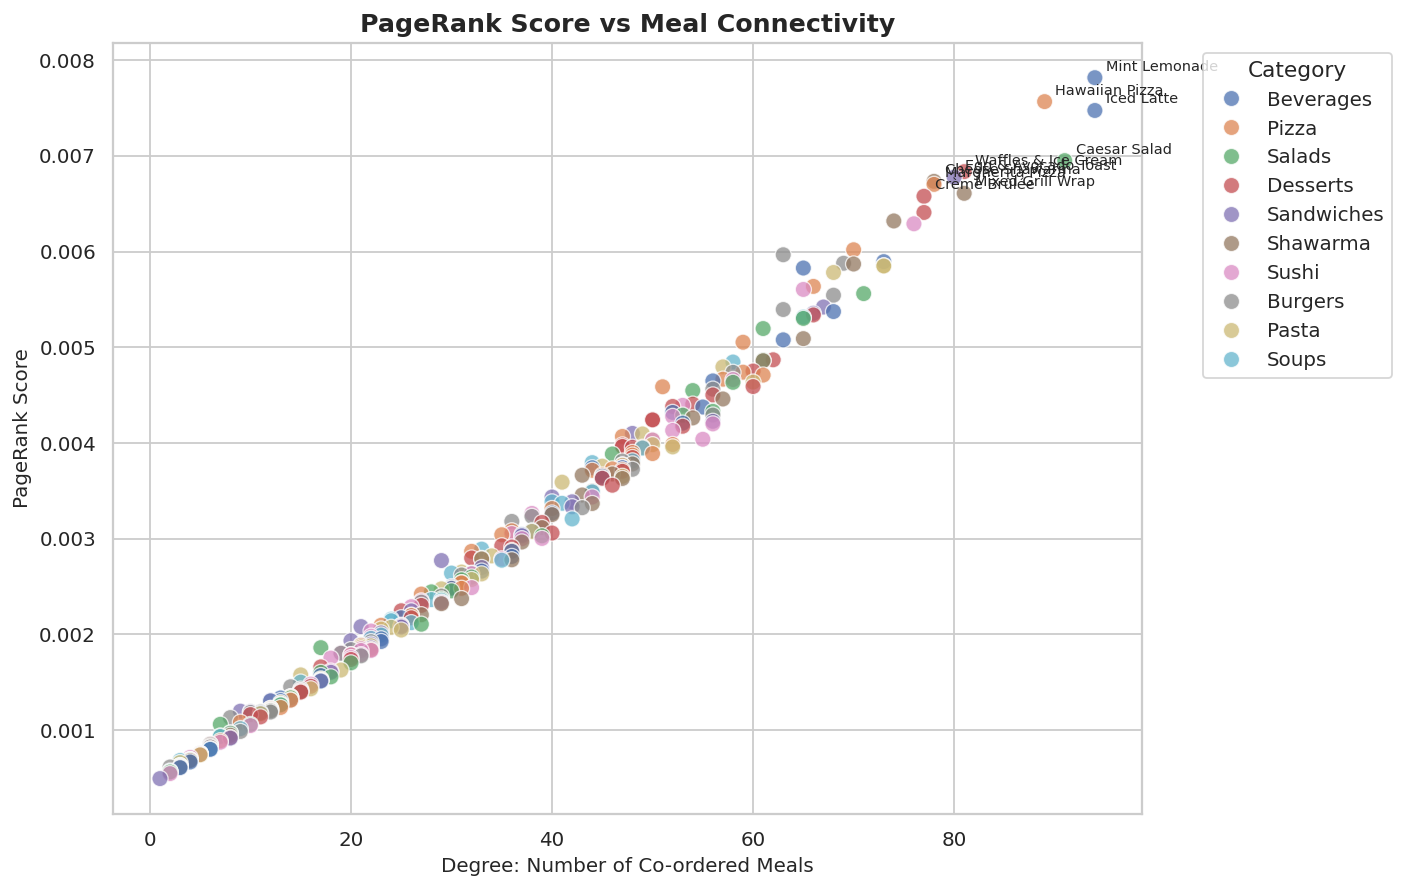

In [33]:
# ============================================================
# PageRank — Score vs Connectivity
# ============================================================

plt.figure(figsize=(11, 7))

ax = sns.scatterplot(
    data=pagerank_df,
    x="degree",
    y="pagerank_score",
    hue="category",
    s=80,
    alpha=0.75
)

# Annotate top 10 PageRank meals
for _, row in pagerank_df.head(10).iterrows():
    ax.annotate(
        row["meal_name"],
        (row["degree"], row["pagerank_score"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8
    )

ax.set_title("PageRank Score vs Meal Connectivity")
ax.set_xlabel("Degree: Number of Co-ordered Meals")
ax.set_ylabel("PageRank Score")
ax.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
save_figure("11_pagerank_vs_degree.png")
plt.show()

✅ Saved: output\figures\12_pagerank_network_graph.png


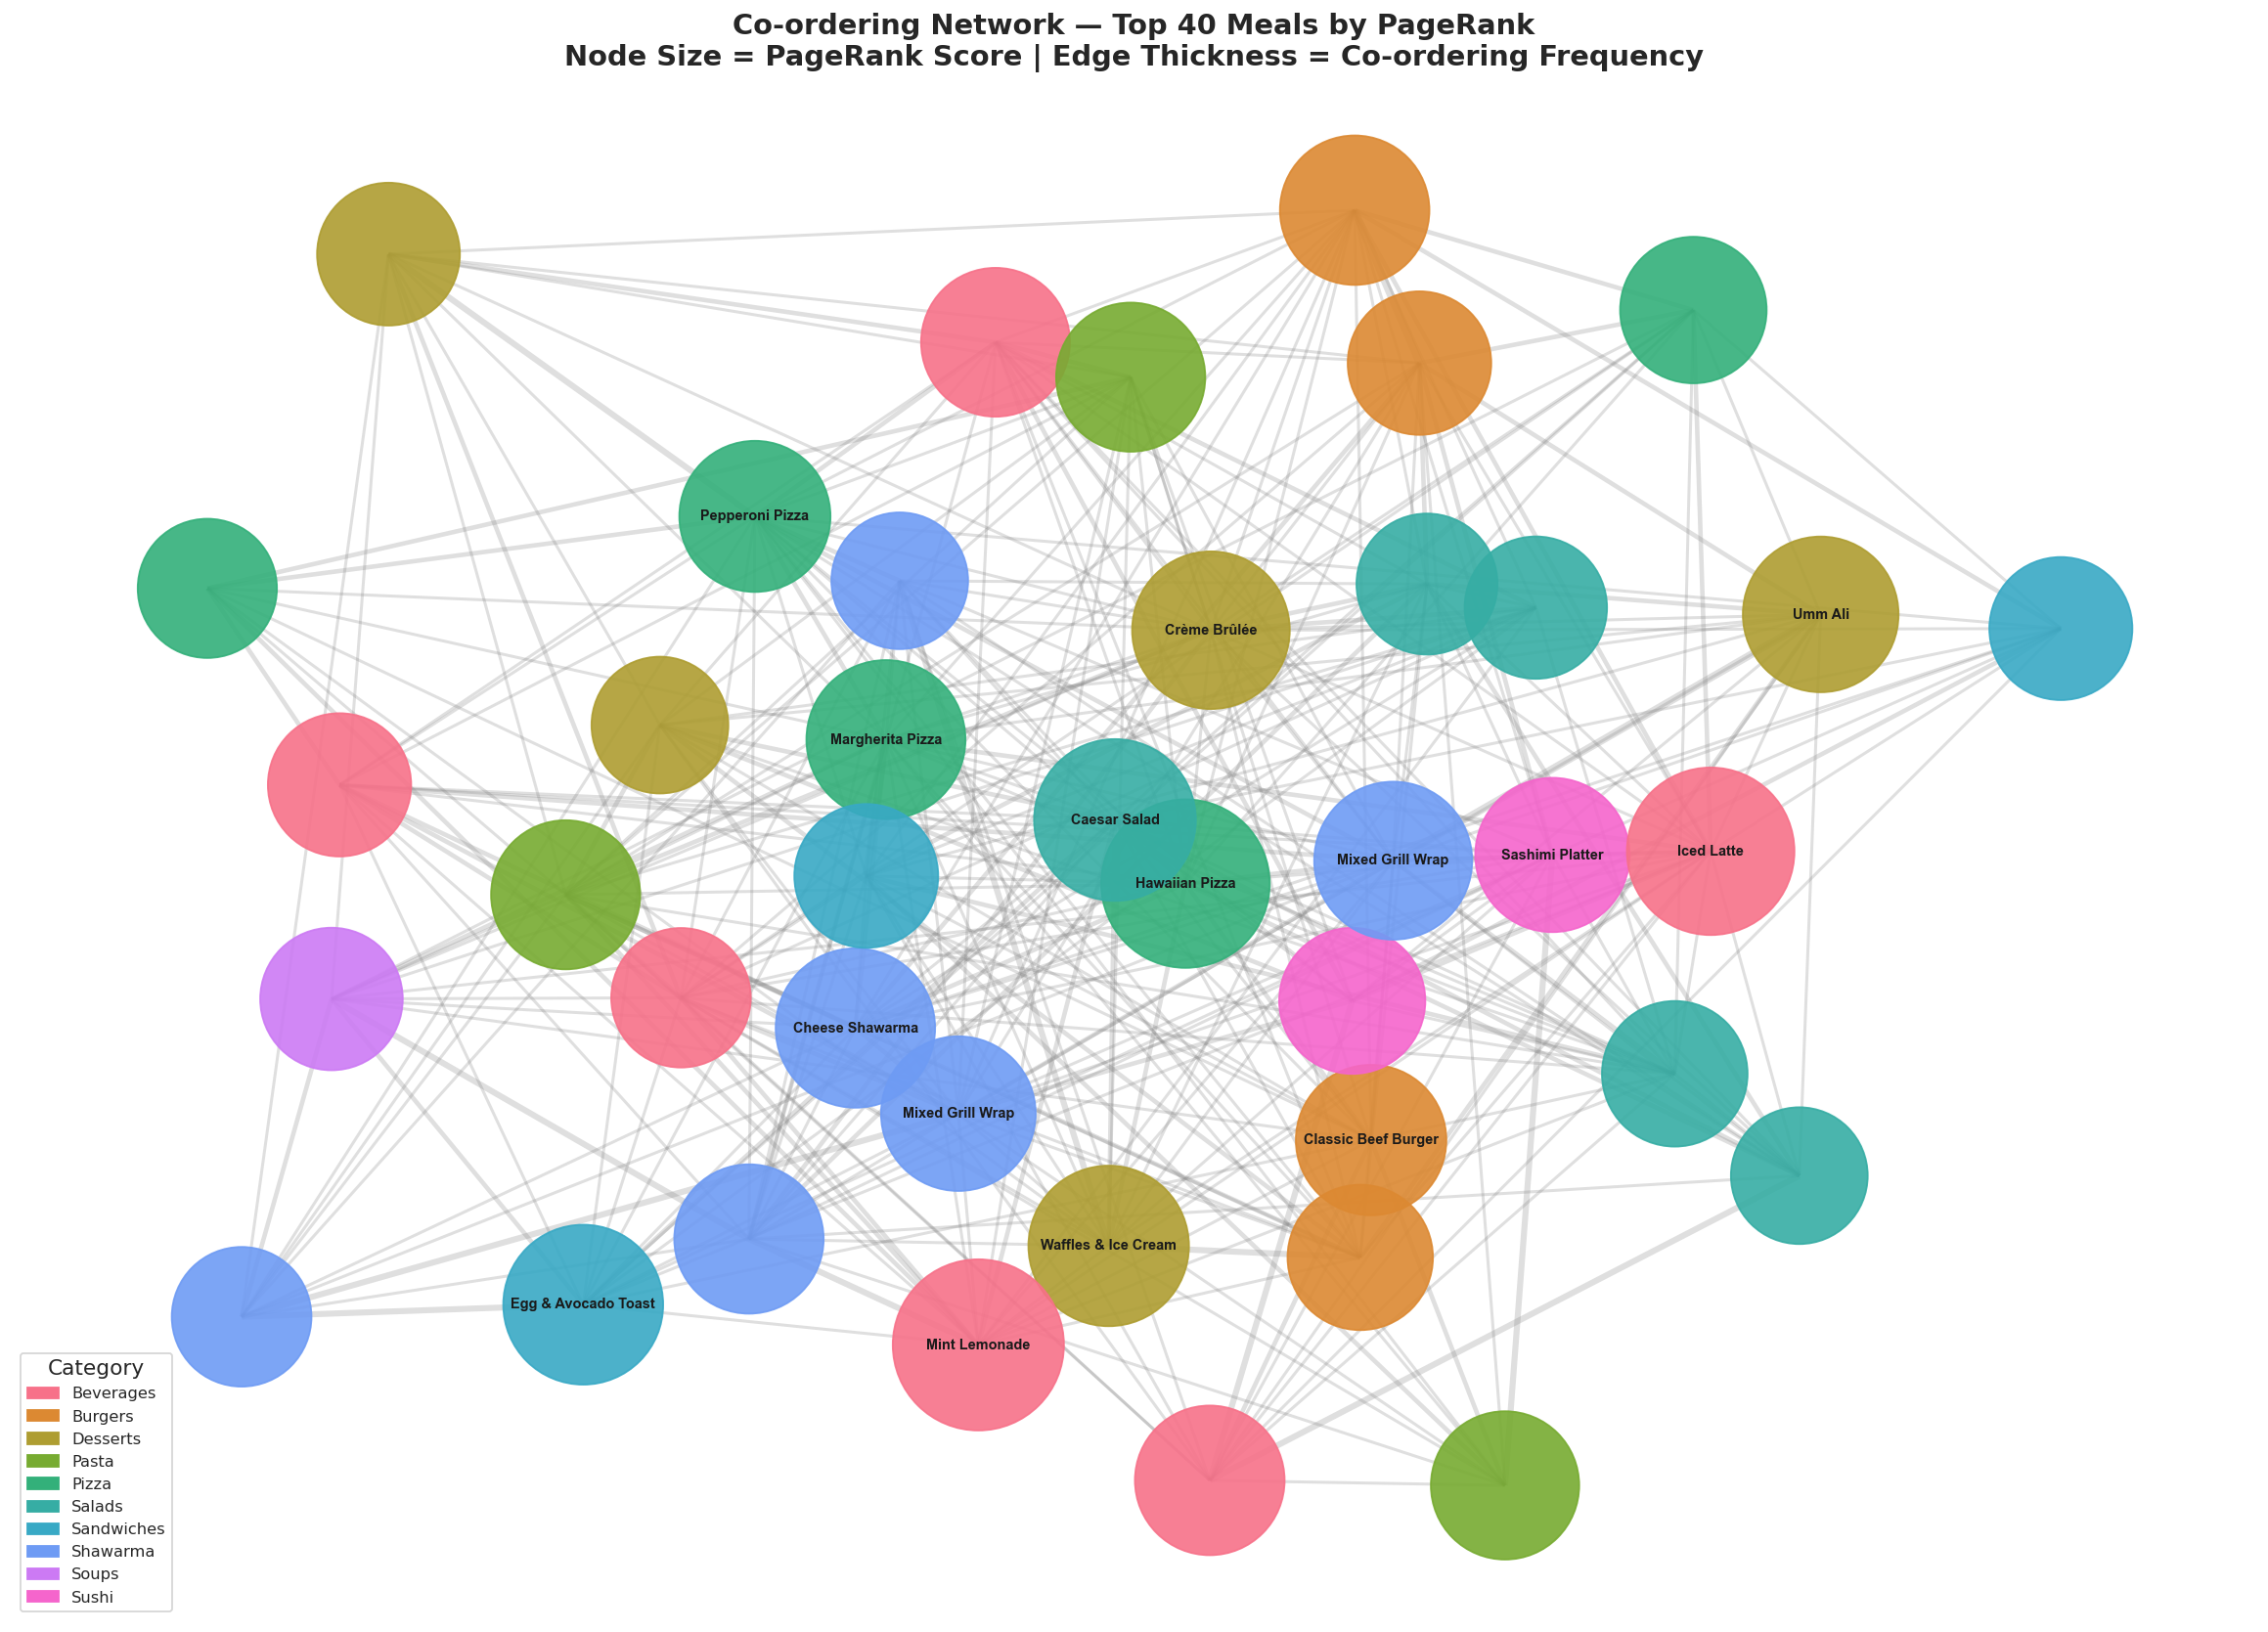

In [34]:
# ============================================================
# PageRank — Co-ordering Network Graph
# ============================================================

top_nodes = set(pagerank_df.head(40)["meal_id"])

H = G.subgraph(top_nodes).copy()

# Node sizes based on PageRank
node_scores = {node: pagerank_scores[node] for node in H.nodes()}
max_score = max(node_scores.values())

node_sizes = [
    9000 * (node_scores[node] / max_score) + 400
    for node in H.nodes()
]

# Node colors by category
node_categories = [
    meal_lookup[node]["category"]
    for node in H.nodes()
]

unique_categories = sorted(set(node_categories))
palette = sns.color_palette("husl", len(unique_categories))
category_colors = {
    category: palette[i]
    for i, category in enumerate(unique_categories)
}

node_colors = [
    category_colors[meal_lookup[node]["category"]]
    for node in H.nodes()
]

# Edge widths based on co-ordering weight
edge_weights = [
    H[u][v]["weight"]
    for u, v in H.edges()
]

max_edge_weight = max(edge_weights) if edge_weights else 1
edge_widths = [
    0.8 + 3.5 * (weight / max_edge_weight)
    for weight in edge_weights
]

plt.figure(figsize=(18, 13))

pos = nx.spring_layout(H, seed=42, k=1.7)

nx.draw_networkx_edges(
    H,
    pos,
    width=edge_widths,
    alpha=0.25,
    edge_color="gray"
)

nx.draw_networkx_nodes(
    H,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.90
)

# Label only top 15 meals to avoid clutter
top15_ids = set(pagerank_df.head(15)["meal_id"])

labels = {
    node: meal_lookup[node]["meal_name"].split("(")[0].strip()
    for node in H.nodes()
    if node in top15_ids
}

nx.draw_networkx_labels(
    H,
    pos,
    labels=labels,
    font_size=8,
    font_weight="bold"
)

# Legend
import matplotlib.patches as mpatches

legend_patches = [
    mpatches.Patch(color=category_colors[category], label=category)
    for category in unique_categories
]

plt.legend(
    handles=legend_patches,
    title="Category",
    loc="lower left",
    fontsize=9
)

plt.title(
    "Co-ordering Network — Top 40 Meals by PageRank\n"
    "Node Size = PageRank Score | Edge Thickness = Co-ordering Frequency",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()
save_figure("12_pagerank_network_graph.png")
plt.show()

In [35]:
# ============================================================
# PageRank — Report Insights
# ============================================================

top_meal = pagerank_df.iloc[0]
top_category = avg_category_pr.index[0]

print("PageRank Insights:")
print(f"- Total meals represented as graph nodes: {G.number_of_nodes():,}")
print(f"- Total co-ordering relationships represented as edges: {G.number_of_edges():,}")
print(f"- The graph is connected: {nx.is_connected(G)}")
print()
print(f"- Most influential meal by PageRank: {top_meal['meal_name']} ({top_meal['category']})")
print(f"  PageRank Score: {top_meal['pagerank_score']:.5f}")
print(f"  Degree: {top_meal['degree']}")
print(f"  Weighted Degree: {top_meal['weighted_degree']}")
print()
print(f"- Highest average PageRank category: {top_category}")
print()
print("Interpretation:")
print(
    "PageRank identifies meals that are not only frequently co-ordered, but also connected "
    "to other influential meals. These meals can be used as strong anchors in recommendation "
    "systems, promotional bundles, and menu placement decisions."
)

PageRank Insights:
- Total meals represented as graph nodes: 355
- Total co-ordering relationships represented as edges: 5,890
- The graph is connected: True

- Most influential meal by PageRank: Mint Lemonade (Beverages)
  PageRank Score: 0.00782
  Degree: 94
  Weighted Degree: 111

- Highest average PageRank category: Desserts

Interpretation:
PageRank identifies meals that are not only frequently co-ordered, but also connected to other influential meals. These meals can be used as strong anchors in recommendation systems, promotional bundles, and menu placement decisions.


In [36]:
# ============================================================
# Sentiment Analysis — Load Results
# ============================================================

if os.path.exists(REVIEWS_SENTIMENT_PATH):
    sentiment_df = pd.read_csv(REVIEWS_SENTIMENT_PATH)
    print("✅ Sentiment results loaded")
    print("Shape:", sentiment_df.shape)
    display(sentiment_df.head())
    print("Columns:", sentiment_df.columns.tolist())
else:
    sentiment_df = None
    print("❌ reviews_with_sentiment.csv not found.")
    print("Expected path:", REVIEWS_SENTIMENT_PATH)

✅ Sentiment results loaded
Shape: (1835, 5)


,review_id,meal_id,review_text,sentiment,sentiment_score
0,R000001,M0001,Disappointed with the quality. Not what I expe...,NEGATIVE,-1
1,R000002,M0001,"Pretty good, I've had better but wouldn't say ...",NEGATIVE,-1
2,R000003,M0001,Super fast delivery and the food was outstandi...,POSITIVE,1
3,R000004,M0001,Perfect seasoning and amazing presentation. Wo...,POSITIVE,1
4,R000005,M0001,Loved every bite. The packaging was also excel...,POSITIVE,1


Columns: ['review_id', 'meal_id', 'review_text', 'sentiment', 'sentiment_score']


In [37]:
# ============================================================
# Sentiment Analysis — Prepare and Merge with Meals Data
# ============================================================

print("Meals columns:", meals_df.columns.tolist())

# Try to detect the correct column names automatically
meal_id_col = None
meal_name_col = None
category_col = None

for col in meals_df.columns:
    cl = col.lower().strip()
    
    if cl in ["meal_id", "item_id", "id"]:
        meal_id_col = col
    elif cl in ["meal_name", "item_name", "name", "meal"]:
        meal_name_col = col
    elif cl in ["category", "meal_category", "item_category"]:
        category_col = col

print("Detected columns:")
print("meal_id_col =", meal_id_col)
print("meal_name_col =", meal_name_col)
print("category_col =", category_col)

# Keep only required columns
merge_cols = [c for c in [meal_id_col, meal_name_col, category_col] if c is not None]
meal_info_df = meals_df[merge_cols].copy()

# Rename for consistency
rename_dict = {}
if meal_id_col is not None:
    rename_dict[meal_id_col] = "meal_id"
if meal_name_col is not None:
    rename_dict[meal_name_col] = "meal_name"
if category_col is not None:
    rename_dict[category_col] = "category"

meal_info_df = meal_info_df.rename(columns=rename_dict)

# Merge
sentiment_merged_df = sentiment_df.merge(
    meal_info_df,
    on="meal_id",
    how="left"
)

print("✅ Sentiment merged with meal information")
print("Shape:", sentiment_merged_df.shape)
display(sentiment_merged_df.head())

Meals columns: ['meal_id', 'meal_name', 'category', 'restaurant', 'brand', 'price_egp', 'description', 'nutrition_grade', 'energy_kcal', 'fat_g', 'carbs_g', 'protein_g', 'image_url', 'rating', 'num_ratings', 'prep_time_min', 'is_available', 'source', 'calories', 'scraped_at']
Detected columns:
meal_id_col = meal_id
meal_name_col = meal_name
category_col = category
✅ Sentiment merged with meal information
Shape: (1835, 7)


,review_id,meal_id,review_text,sentiment,sentiment_score,meal_name,category
0,R000001,M0001,Disappointed with the quality. Not what I expe...,NEGATIVE,-1,Classic Beef Burger,Burgers
1,R000002,M0001,"Pretty good, I've had better but wouldn't say ...",NEGATIVE,-1,Classic Beef Burger,Burgers
2,R000003,M0001,Super fast delivery and the food was outstandi...,POSITIVE,1,Classic Beef Burger,Burgers
3,R000004,M0001,Perfect seasoning and amazing presentation. Wo...,POSITIVE,1,Classic Beef Burger,Burgers
4,R000005,M0001,Loved every bite. The packaging was also excel...,POSITIVE,1,Classic Beef Burger,Burgers


✅ Saved: output\figures\13_sentiment_distribution.png


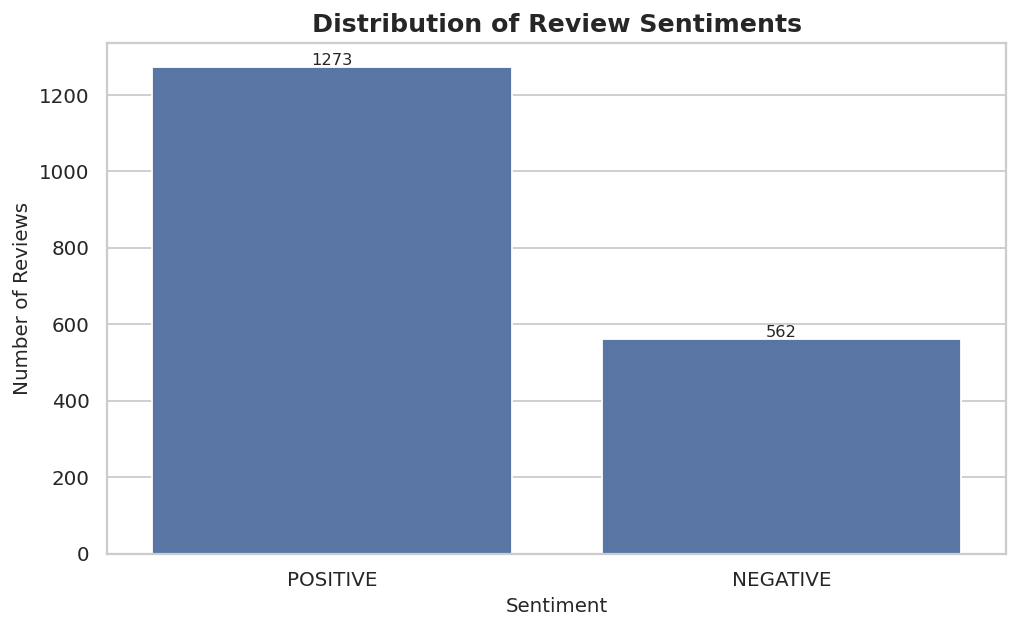

In [38]:
# ============================================================
# Sentiment Analysis — Sentiment Distribution
# ============================================================

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=sentiment_merged_df,
    x="sentiment",
    order=sentiment_merged_df["sentiment"].value_counts().index
)

ax.set_title("Distribution of Review Sentiments")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Reviews")

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"{int(height)}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
save_figure("13_sentiment_distribution.png")
plt.show()

✅ Saved: output\figures\14_sentiment_score_distribution.png


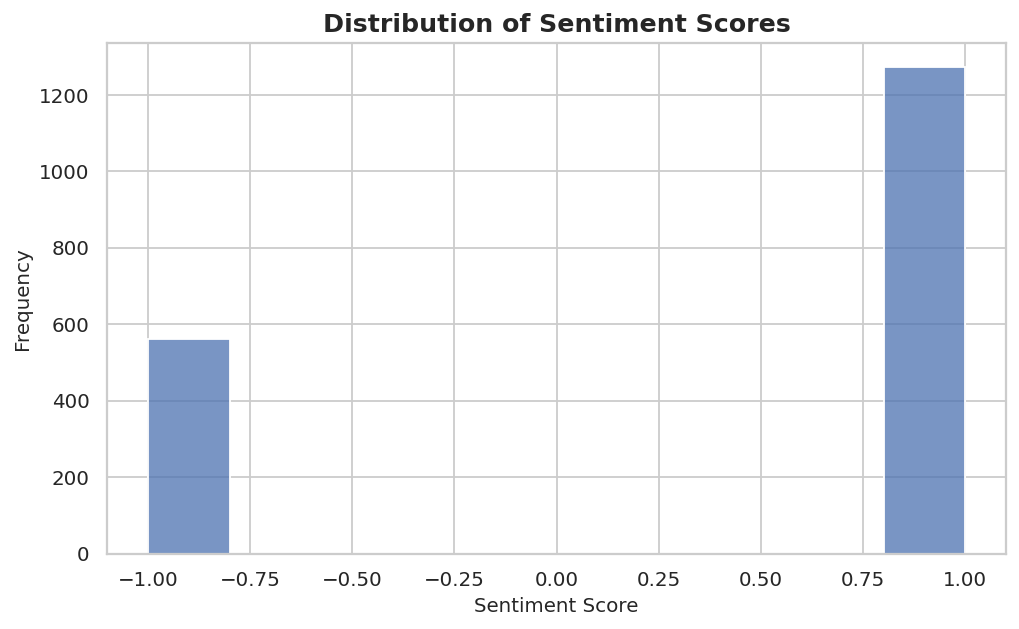

In [39]:
# ============================================================
# Sentiment Analysis — Sentiment Score Distribution
# ============================================================

plt.figure(figsize=(8, 5))

ax = sns.histplot(
    sentiment_merged_df["sentiment_score"],
    bins=10,
    kde=False
)

ax.set_title("Distribution of Sentiment Scores")
ax.set_xlabel("Sentiment Score")
ax.set_ylabel("Frequency")

plt.tight_layout()
save_figure("14_sentiment_score_distribution.png")
plt.show()

,category,avg_sentiment_score,review_count
0,Salads,0.500000,160
1,Pizza,0.484444,225
2,Sushi,0.457143,210
3,Pasta,0.394286,175
4,Beverages,0.385366,205
5,Desserts,0.356098,205
6,Burgers,0.343590,195
7,Sandwiches,0.328571,140
8,Soups,0.293333,150
9,Shawarma,0.282353,170


✅ Saved: output\figures\15_avg_sentiment_by_category.png


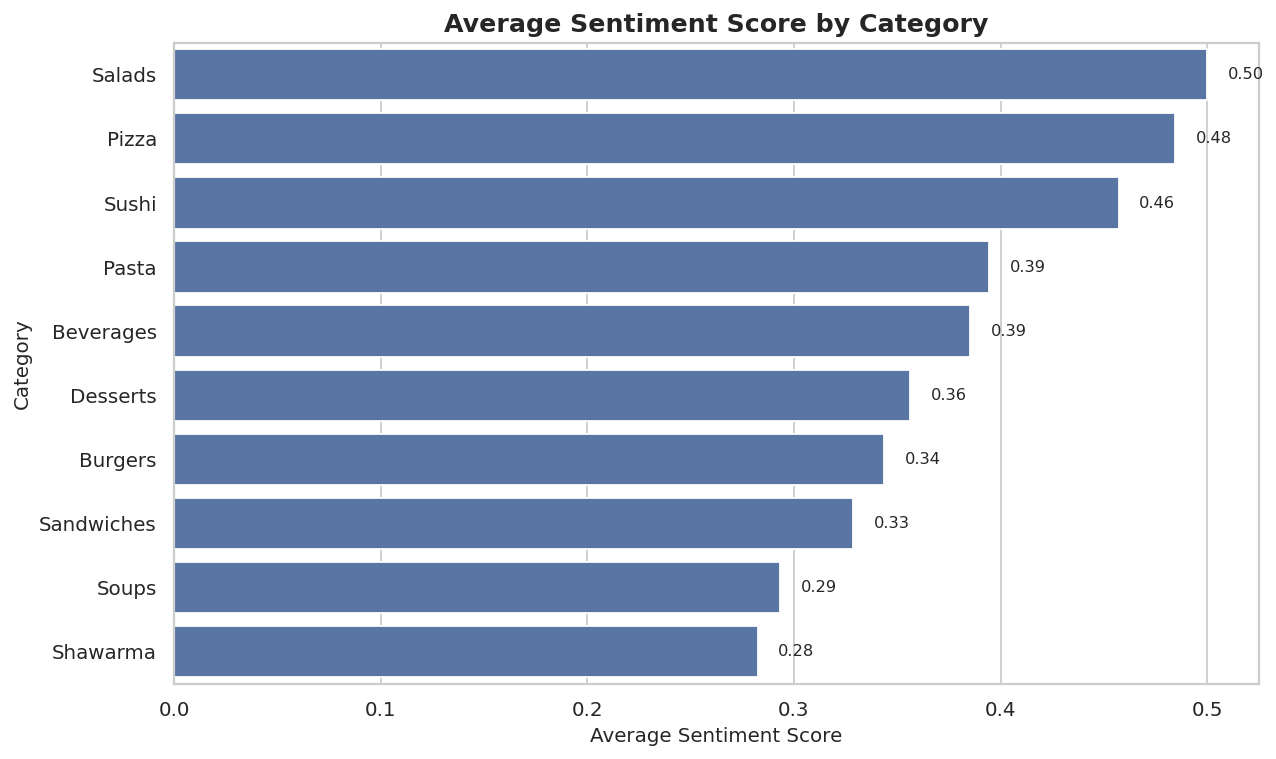

In [40]:
# ============================================================
# Sentiment Analysis — Average Sentiment by Category
# ============================================================

category_sentiment = (
    sentiment_merged_df
    .dropna(subset=["category"])
    .groupby("category")
    .agg(
        avg_sentiment_score=("sentiment_score", "mean"),
        review_count=("review_id", "count")
    )
    .sort_values("avg_sentiment_score", ascending=False)
    .reset_index()
)

display(category_sentiment)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_sentiment,
    x="avg_sentiment_score",
    y="category"
)

ax.set_title("Average Sentiment Score by Category")
ax.set_xlabel("Average Sentiment Score")
ax.set_ylabel("Category")

for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
save_figure("15_avg_sentiment_by_category.png")
plt.show()

,meal_name,category,avg_sentiment_score,review_count
4,Caesar Salad,Salads,0.500000,40
41,Mushroom Cream Soup,Soups,0.520000,25
47,Pesto Pasta,Pasta,0.520000,25
57,Spicy Tuna Roll (8Pcs),Sushi,0.533333,30
17,Dragon Roll (8Pcs),Sushi,0.533333,30
48,Quinoa Power Bowl,Salads,0.600000,30
30,Iced Latte,Beverages,0.600000,20
45,Penne Arrabiata,Pasta,0.600000,20
3,Blt Sandwich,Sandwiches,0.600000,25
62,Truffle Mushroom Pizza,Pizza,0.600000,15


✅ Saved: output\figures\16_top15_meals_by_sentiment.png


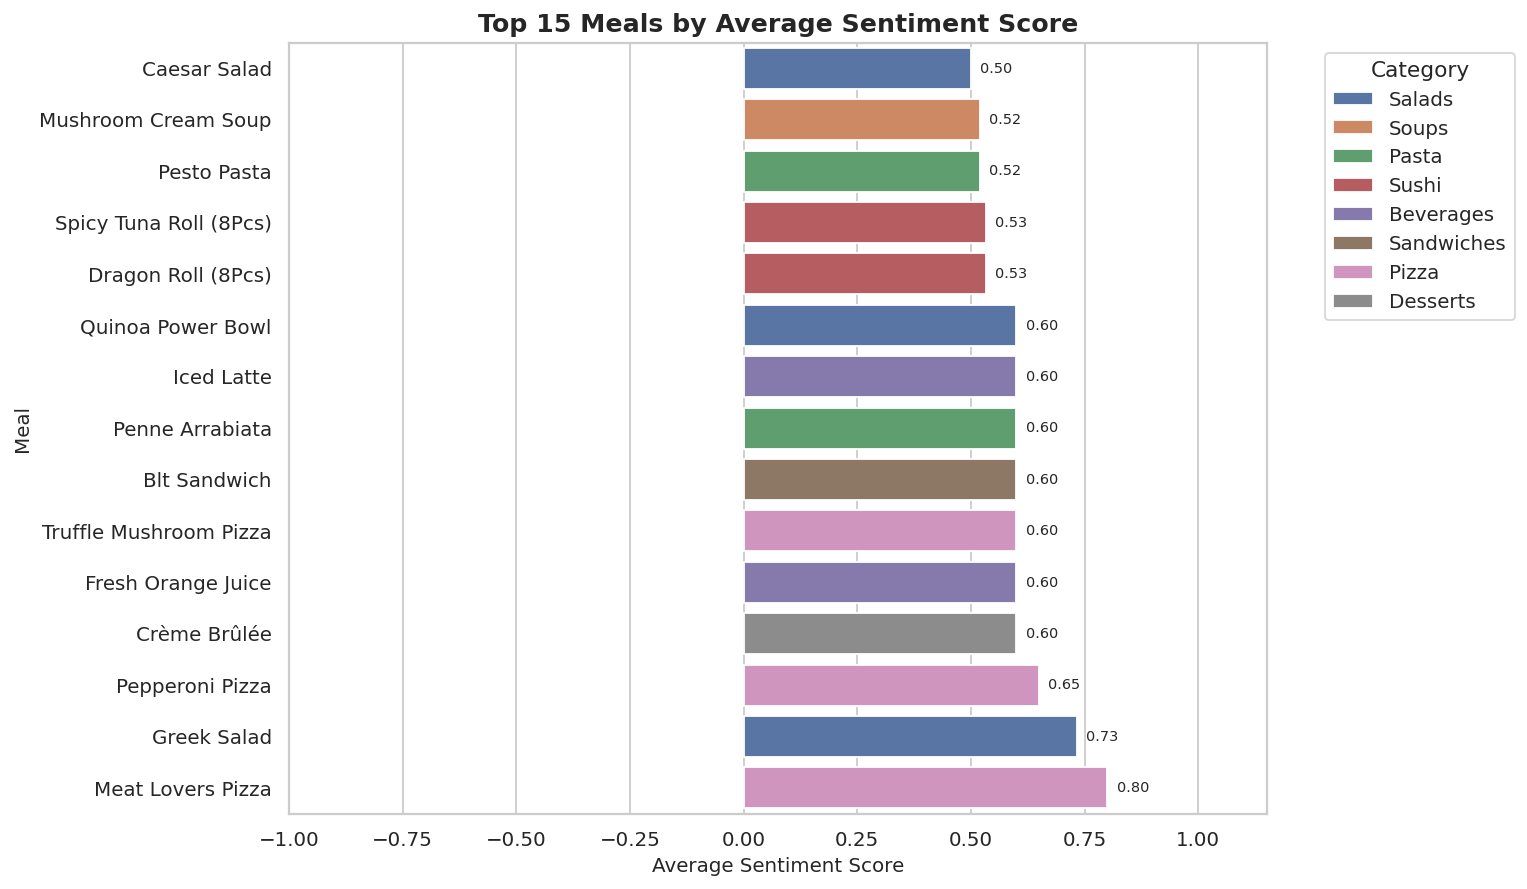

In [47]:
# ============================================================
# Sentiment Analysis — Top Meals by Average Sentiment
# Aggregated by meal name to avoid duplicates
# ============================================================

meal_sentiment = (
    sentiment_merged_df
    .dropna(subset=["meal_name"])
    .groupby(["meal_name", "category"])
    .agg(
        avg_sentiment_score=("sentiment_score", "mean"),
        review_count=("review_id", "count")
    )
    .reset_index()
)

# Keep meals with enough reviews
meal_sentiment_filtered = meal_sentiment[meal_sentiment["review_count"] >= 5].copy()

top_positive_meals = (
    meal_sentiment_filtered
    .sort_values(["avg_sentiment_score", "review_count"], ascending=[False, False])
    .head(15)
    .sort_values("avg_sentiment_score")
)

display(top_positive_meals)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_positive_meals,
    x="avg_sentiment_score",
    y="meal_name",
    hue="category",
    dodge=False
)

ax.set_title("Top 15 Meals by Average Sentiment Score")
ax.set_xlabel("Average Sentiment Score")
ax.set_ylabel("Meal")
ax.set_xlim(-1, 1.15)

for bar in ax.patches:
    width = bar.get_width()
    if width > 0.001:
        ax.text(
            width + 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.2f}",
            va="center",
            fontsize=8
        )

ax.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
save_figure("16_top15_meals_by_sentiment.png")
plt.show()

In [43]:
# ============================================================
# Recommendation System — Combine PageRank with Sentiment
# ============================================================

# Prepare sentiment summary per meal
meal_sentiment_summary = (
    sentiment_merged_df
    .dropna(subset=["meal_name"])
    .groupby(["meal_id", "meal_name", "category"])
    .agg(
        avg_sentiment_score=("sentiment_score", "mean"),
        review_count=("review_id", "count")
    )
    .reset_index()
)

# Merge with pagerank
recommendation_df = pagerank_df.merge(
    meal_sentiment_summary[["meal_id", "avg_sentiment_score", "review_count"]],
    on="meal_id",
    how="left"
)

# Fill missing sentiment with 0
recommendation_df["avg_sentiment_score"] = recommendation_df["avg_sentiment_score"].fillna(0)
recommendation_df["review_count"] = recommendation_df["review_count"].fillna(0)

# Normalize PageRank
recommendation_df["pagerank_norm"] = (
    (recommendation_df["pagerank_score"] - recommendation_df["pagerank_score"].min()) /
    (recommendation_df["pagerank_score"].max() - recommendation_df["pagerank_score"].min())
)

# Normalize sentiment from [-1, 1] to [0, 1]
recommendation_df["sentiment_norm"] = (
    (recommendation_df["avg_sentiment_score"] + 1) / 2
)

# Final recommendation score
recommendation_df["recommendation_score"] = (
    0.7 * recommendation_df["pagerank_norm"] +
    0.3 * recommendation_df["sentiment_norm"]
)

top_recommendations = (
    recommendation_df
    .sort_values("recommendation_score", ascending=False)
    .head(15)
    .sort_values("recommendation_score")
)

display(
    top_recommendations[
        ["meal_name", "category", "pagerank_score", "avg_sentiment_score", "review_count", "recommendation_score"]
    ]
)

,meal_name,category,pagerank_score,avg_sentiment_score,review_count,recommendation_score
5,Egg & Avocado Toast,Sandwiches,0.006777,0.2,5,0.780666
23,Rainbow Roll (8Pcs),Sushi,0.005604,1.0,5,0.788497
12,Sashimi Platter (12Pcs),Sushi,0.006290,0.6,5,0.794086
10,Umm Ali,Desserts,0.006408,0.6,5,0.805391
21,Spaghetti Bolognese,Pasta,0.005781,1.0,5,0.805437
18,Spaghetti Bolognese,Pasta,0.005850,1.0,5,0.812039
14,Classic Beef Burger,Burgers,0.005966,1.0,5,0.823152
4,Waffles & Ice Cream,Desserts,0.006834,0.6,5,0.846147
2,Iced Latte,Beverages,0.007473,0.2,5,0.847244
11,Mixed Grill Wrap,Shawarma,0.006319,1.0,5,0.856912


In [44]:
# ============================================================
# Sentiment Analysis — Report Insights
# ============================================================

top_sentiment_category = category_sentiment.iloc[0]
top_recommended_meal = top_recommendations.iloc[-1]

print("Sentiment Insights:")
print(f"- Total analyzed reviews: {len(sentiment_merged_df):,}")
print(f"- Most frequent sentiment label: {sentiment_merged_df['sentiment'].mode()[0]}")
print(f"- Highest average sentiment category: {top_sentiment_category['category']}")
print(f"  Average Sentiment Score: {top_sentiment_category['avg_sentiment_score']:.2f}")
print()
print("Recommendation Insight:")
print(f"- Top recommended meal after combining PageRank and sentiment: {top_recommended_meal['meal_name']} ({top_recommended_meal['category']})")
print(f"  PageRank Score: {top_recommended_meal['pagerank_score']:.5f}")
print(f"  Average Sentiment Score: {top_recommended_meal['avg_sentiment_score']:.2f}")
print(f"  Final Recommendation Score: {top_recommended_meal['recommendation_score']:.2f}")
print()
print("Interpretation:")
print(
    "PageRank highlights meals that are influential in the co-ordering network, while sentiment analysis "
    "captures customer satisfaction. Combining both produces more balanced recommendations: meals that are "
    "popular, connected, and positively perceived by customers."
)

Sentiment Insights:
- Total analyzed reviews: 1,835
- Most frequent sentiment label: POSITIVE
- Highest average sentiment category: Salads
  Average Sentiment Score: 0.50

Recommendation Insight:
- Top recommended meal after combining PageRank and sentiment: Mint Lemonade (Beverages)
  PageRank Score: 0.00782
  Average Sentiment Score: 1.00
  Final Recommendation Score: 1.00

Interpretation:
PageRank highlights meals that are influential in the co-ordering network, while sentiment analysis captures customer satisfaction. Combining both produces more balanced recommendations: meals that are popular, connected, and positively perceived by customers.


In [48]:
# ============================================================
# Final Project Summary and Conclusions
# ============================================================

print("=" * 70)
print("FINAL SUMMARY — FOOD DELIVERY PATTERN ANALYSIS")
print("=" * 70)

print("\n1. Dataset Overview")
print(f"- Total orders analyzed: {len(transactions_df):,}")
print(f"- Unique customers: {transactions_df['customer_id'].nunique():,}")
print(f"- Unique restaurants: {transactions_df['restaurant'].nunique():,}")
print(f"- Average items per order: {transactions_df['n_items'].mean():.2f}")
print(f"- Average order rating: {transactions_df['order_rating'].mean():.2f}/5")

print("\n2. Association Rule Mining")
print(f"- Total association rules generated: {len(rules_df):,}")
print(f"- Highest-lift rule: {rules_df.iloc[0]['rule']}")
print(f"- Highest lift score: {rules_df.iloc[0]['lift']:.2f}")

print("\n3. PageRank / Link Analysis")
print(f"- Meals represented as graph nodes: {G.number_of_nodes():,}")
print(f"- Co-ordering relationships represented as edges: {G.number_of_edges():,}")
print(f"- Most influential meal: {pagerank_df.iloc[0]['meal_name']} ({pagerank_df.iloc[0]['category']})")
print(f"- PageRank score: {pagerank_df.iloc[0]['pagerank_score']:.5f}")

print("\n4. Sentiment Analysis")
print(f"- Reviews analyzed: {len(sentiment_merged_df):,}")
print(f"- Most frequent sentiment: {sentiment_merged_df['sentiment'].mode()[0]}")
print(f"- Highest average sentiment category: {category_sentiment.iloc[0]['category']}")

print("\n5. Final Recommendation Output")
print(f"- Top recommended meal: {top_recommendations.iloc[-1]['meal_name']} ({top_recommendations.iloc[-1]['category']})")
print(f"- Final recommendation score: {top_recommendations.iloc[-1]['recommendation_score']:.2f}")

print("\nConclusion:")
print(
    "The project shows how transaction mining, graph-based ranking, and sentiment analysis "
    "can work together to improve food recommendation systems. Association rules identify "
    "frequently co-ordered meal combinations, PageRank identifies influential meals in the "
    "co-ordering network, and sentiment analysis ensures that recommendations also reflect "
    "customer satisfaction. Combining these methods creates a stronger recommendation approach "
    "than relying on order frequency alone."
)

print("\nLimitations:")
print(
    "The dataset includes generated food delivery transactions and sentiment outputs with binary "
    "positive/negative labels. Some high-lift association rules have low support, so they should be "
    "interpreted as exploratory patterns rather than final business decisions."
)

FINAL SUMMARY — FOOD DELIVERY PATTERN ANALYSIS

1. Dataset Overview
- Total orders analyzed: 2,000
- Unique customers: 487
- Unique restaurants: 20
- Average items per order: 2.83
- Average order rating: 3.76/5

2. Association Rule Mining
- Total association rules generated: 620
- Highest-lift rule: Truffle Burger, Club Sandwich → Spaghetti Bolognese, Iced Latte
- Highest lift score: 200.00

3. PageRank / Link Analysis
- Meals represented as graph nodes: 355
- Co-ordering relationships represented as edges: 5,890
- Most influential meal: Mint Lemonade (Beverages)
- PageRank score: 0.00782

4. Sentiment Analysis
- Reviews analyzed: 1,835
- Most frequent sentiment: POSITIVE
- Highest average sentiment category: Salads

5. Final Recommendation Output
- Top recommended meal: Mint Lemonade (Beverages)
- Final recommendation score: 1.00

Conclusion:
The project shows how transaction mining, graph-based ranking, and sentiment analysis can work together to improve food recommendation systems. 

Final Summary — Food Delivery Pattern Analysis

The project analyzed 2,000 food delivery orders from 487 customers and 20 restaurants. The average basket size was 2.83 items per order, and the average order rating was 3.76 out of 5.

Association Rule Mining generated 620 association rules. The highest-lift rule was:
Truffle Burger, Club Sandwich → Spaghetti Bolognese, Iced Latte
with a lift score of 200.00. This indicates that this combination appeared together more often than expected by chance. However, because some high-lift rules have low support, these rules should be treated as exploratory patterns.

PageRank analysis was applied to a co-ordering graph containing 355 meal nodes and 5,890 co-ordering edges. The most influential meal was Mint Lemonade from the Beverages category, with a PageRank score of 0.00782. This suggests that Mint Lemonade is strongly connected to other frequently co-ordered meals and can be used as a recommendation anchor.

Sentiment analysis was applied to 1,835 customer reviews. The most frequent sentiment was POSITIVE, and the category with the highest average sentiment score was Salads. Since the sentiment output uses binary positive/negative labels, neutral sentiment was not included in the final sentiment analysis.

The final recommendation output combined PageRank influence with sentiment score. The top recommended meal was Mint Lemonade, with a final recommendation score of 1.00. This shows that the recommendation system does not rely only on order frequency, but also considers meal influence in the network and customer satisfaction.

Conclusion:
Transaction mining, graph-based ranking, and sentiment analysis complement each other in building a stronger food recommendation system. Association rules identify frequently co-ordered meal combinations, PageRank highlights influential meals in the co-ordering network, and sentiment analysis ensures that recommendations reflect customer feedback. Combining these methods creates a more balanced recommendation approach than relying on popularity alone.

Limitations:
The dataset includes generated food delivery transactions and sentiment outputs with binary positive/negative labels. In addition, some high-lift association rules have low support, so they should be interpreted as exploratory patterns rather than final business decisions.